In [39]:
import os
import math
import copy
import torch
import random
import argparse


import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import scipy.sparse as sp
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch import nn
from torch import Tensor
from typing import Optional
from torch.nn.parameter import Parameter
from torch_geometric.typing import OptTensor
from torch_sparse import SparseTensor, matmul
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv

from scipy import sparse
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import wasserstein_distance, pearsonr, spearmanr, entropy, ks_2samp, cramervonmises_2samp, ttest_ind, levene

from torch_geometric.utils import degree
from torch_geometric.utils import to_networkx, to_scipy_sparse_matrix


from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

############################################################################

### 데이터셋

In [2]:
def normalize_adj(mx):
    rowsum = np.array(mx.sum(1)).flatten()
    r_inv = np.power(rowsum, -1.0, where=rowsum != 0)
    r_mat_inv = sp.diags(r_inv)
    return r_mat_inv.dot(mx)

def homophily_ratio(edge_index, sensitive_attr):
    edge_index = edge_index.cpu().numpy()
    sens = sensitive_attr.cpu().numpy()
    same = sum(sens[u] == sens[v] for u, v in zip(*edge_index))
    return same / edge_index.shape[1]

def assortativity_coefficient(data):
    G = to_networkx(data, to_undirected=True)
    nx.set_node_attributes(G, {i: int(data.sensitive_attr[i]) for i in range(data.num_nodes)}, "sensitive")
    return nx.attribute_assortativity_coefficient(G, "sensitive")

def local_neighborhood_fairness(edge_index, sensitive_attr):
    edge_index = edge_index.cpu().numpy()
    sens = sensitive_attr.cpu().numpy()
    diffs = []

    for node in range(len(sens)):
        neighbors = edge_index[1][edge_index[0] == node]
        if len(neighbors) > 0:
            local = sens[neighbors].mean()
            global_ = sens.mean()
            diffs.append(abs(local - global_))
    return np.mean(diffs)

def degree_balance(edge_index, sensitive_attr):
    num_nodes = sensitive_attr.size(0)
    degrees = np.bincount(edge_index[0].cpu().numpy(), minlength=num_nodes)
    sens = sensitive_attr.cpu().numpy()
    group0_degrees = degrees[sens == 0]
    group1_degrees = degrees[sens == 1]
    return abs(group0_degrees.mean() - group1_degrees.mean())

def structural_bias(features, edge_index, sens, num_hops=2, alpha=0.9):
    adj = to_scipy_sparse_matrix(edge_index, num_nodes=features.size(0)).tocsr()
    adj = adj + sp.eye(adj.shape[0])
    adj = normalize_adj(adj)
    feat = features.cpu().numpy()
    feat_smooth = feat.copy()
    
    for _ in range(num_hops):
        feat_smooth = alpha * adj.dot(feat_smooth) + (1 - alpha) * feat
    
    sens = sens.cpu().numpy()
    s0 = feat_smooth[sens == 0]
    s1 = feat_smooth[sens == 1]
    emd = np.mean([wasserstein_distance(s0[:, i], s1[:, i]) for i in range(s0.shape[1])])

    return emd

def analyze_structural_bias_with_tests(data, df, sens_attr='sens', y_col='y', y_pred_col='y_pred'):
    df['degree'] = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
    df['error'] = np.abs(df[y_col] - df[y_pred_col])
    summary = df.groupby(sens_attr).agg({
        'degree': ['mean', 'std'],
        'error': ['mean', 'std'],
        y_pred_col: ['var']
    }).round(3)

    print(summary)

    g0 = df[df[sens_attr] == 0]
    g1 = df[df[sens_attr] == 1]
    t_stat, p_ttest = ttest_ind(g0['error'], g1['error'], equal_var=False)
    w_stat, p_levene = levene(g0['error'], g1['error'])
    ks_stat, p_ks = ks_2samp(g0[y_pred_col], g1[y_pred_col])

    print(f"  • t-test:        p = {p_ttest:.4f}")
    print(f"  • Levene test:   p = {p_levene:.4f}")
    print(f"  • KS test:       p = {p_ks:.4f}")

    return {
        'summary': summary,
        'p_ttest_error_mean': p_ttest,
        'p_levene_error_var': p_levene,
        'p_ks_pred_dist': p_ks
    }

def accuracy(output, labels):
    output = output.squeeze()
    preds = (output>0).type_as(labels)
    correct = preds.eq(labels).double()
    correct = correct.sum()
    return correct / len(labels)

def total_variation_distance(p, q):
    return 0.5 * np.sum(np.abs(p - q))

def kl_divergence(p, q):
    p = np.clip(p, 1e-10, 1)
    q = np.clip(q, 1e-10, 1)
    return entropy(p, q)

def js_divergence(p, q):
    return jensenshannon(p, q) ** 2

def distribution_metrics(y_true_np, y_pred_np, bins=50, range=None):
    hist_true, _ = np.histogram(y_true_np, bins=bins, range=range, density=False)
    hist_pred, _ = np.histogram(y_pred_np, bins=bins, range=range, density=False)

    hist_true = hist_true.astype(np.float64)
    hist_pred = hist_pred.astype(np.float64)

    hist_true += 1e-10
    hist_pred += 1e-10
    hist_true /= hist_true.sum()
    hist_pred /= hist_pred.sum()

    return {
        'wasserstein': wasserstein_distance(y_true_np, y_pred_np),
        'kl': kl_divergence(hist_true, hist_pred),
        'js': js_divergence(hist_true, hist_pred),
        'ks': ks_2samp(y_true_np, y_pred_np).statistic,
        'cvm': cramervonmises_2samp(y_true_np, y_pred_np).statistic,
        'tv': total_variation_distance(hist_true, hist_pred)
    }

def group_distribution_metrics(y_true_np, y_pred_np, sensitive_attr_np, bins=50, range=None):
    groups = np.unique(sensitive_attr_np.astype(int))
    if len(groups) != 2:
        raise ValueError(f"필요한 그룹(0, 1) 중 일부가 누락되었습니다. 존재하는 그룹: {groups}")

    results = {}
    metrics = ['wasserstein', 'kl', 'js', 'ks', 'cvm', 'tv']
    group_metrics = {}

    for g in groups:
        idx = sensitive_attr_np == g
        group_metrics[f"group_{g}"] = distribution_metrics(y_true_np[idx], y_pred_np[idx], bins=bins, range=range)

    for m in metrics:
        try:
            diff = abs(group_metrics["group_0"][m] - group_metrics["group_1"][m])
            results[f"{m}_diff"] = diff
            results[f"{m}_g0"] = group_metrics["group_0"][m]
            results[f"{m}_g1"] = group_metrics["group_1"][m]
        except KeyError as e:
            raise KeyError(f"그룹별 지표 계산 중 '{e}' 누락. 현재 그룹들: {group_metrics.keys()}")
    return results

def fair_metric(output, labels, sens, idx):
    val_y = labels[idx].cpu().numpy()
    idx_s0 = sens.cpu().numpy()[idx.cpu().numpy()]==0
    idx_s1 = sens.cpu().numpy()[idx.cpu().numpy()]>0

    idx_s0_y1 = np.bitwise_and(idx_s0,val_y>0)
    idx_s1_y1 = np.bitwise_and(idx_s1,val_y>0)

    pred_y = (output[idx].squeeze()>0.5).type_as(labels).cpu().numpy()

    parity = abs(sum(pred_y[idx_s0])/sum(idx_s0)-sum(pred_y[idx_s1])/sum(idx_s1))
    equality = abs(sum(pred_y[idx_s0_y1])/sum(idx_s0_y1)-sum(pred_y[idx_s1_y1])/sum(idx_s1_y1))

    return parity, equality

def compute_graph_fairness_stats(data, edge_index):
    sens = data.sensitive_attr.cpu().numpy()
    labels = data.y.cpu().numpy()
    src, dst = edge_index[0].cpu().numpy(), edge_index[1].cpu().numpy()
    num_nodes = len(sens)

    print("========== Dataset Summary ==========")
    print(f"Total nodes: {num_nodes}")
    print(f"Total edges: {edge_index.shape[1]}")

    # 1. 민감 속성 분포
    g0, g1 = np.sum(sens == 0), np.sum(sens == 1)
    print("\n--- Sensitive Attribute Distribution ---")
    print(f"Group 0: {g0} ({g0/num_nodes:.2%})")
    print(f"Group 1: {g1} ({g1/num_nodes:.2%})")

    # 2. 예측값 분포
    print("\n--- Label Distribution ---")
    print(f"Overall: mean={labels.mean():.4f}, std={labels.std():.4f}")
    print(f"Group 0: mean={labels[sens==0].mean():.4f}, std={labels[sens==0].std():.4f}")
    print(f"Group 1: mean={labels[sens==1].mean():.4f}, std={labels[sens==1].std():.4f}")

    # 3. 상관관계
    pear, _ = pearsonr(sens, labels)
    spear, _ = spearmanr(sens, labels)
    print("\n--- Correlation (Sensitive vs Label) ---")
    print(f"Pearson:  {pear:.4f}")
    print(f"Spearman: {spear:.4f}")

    # 4. Homophily
    def homophily(attr):
        return np.mean(attr[src] == attr[dst])
    sens_hom = homophily(sens)
    label_hom = homophily(labels.round())  # 연속형 label인 경우 이진화
    print("\n--- Graph Homophily ---")
    print(f"Sensitive attribute homophily: {sens_hom:.4f}")
    print(f"Label homophily: {label_hom:.4f}")

    # 5. Group별 node degree
    degree = np.bincount(src, minlength=num_nodes)
    deg_g0 = degree[sens == 0]
    deg_g1 = degree[sens == 1]
    print("\n--- Node Degree (per group) ---")
    print(f"Group 0: mean={deg_g0.mean():.2f}, std={deg_g0.std():.2f}")
    print(f"Group 1: mean={deg_g1.mean():.2f}, std={deg_g1.std():.2f}")

    # 6. 이웃 구성 동질성 (각 노드 이웃 중 같은 그룹 비율 평균)
    same_group_ratios = []
    for i in range(num_nodes):
        neighbors = dst[src == i]
        if len(neighbors) > 0:
            same_ratio = np.mean(sens[neighbors] == sens[i])
            same_group_ratios.append(same_ratio)
    print("\n--- Neighborhood Composition ---")
    print(f"Average same-group neighbor ratio: {np.mean(same_group_ratios):.4f}")

def fair_metric_regression(output, labels, sens):
    y_g0 = output[sens == 0]
    y_g1 = output[sens == 1]
    
    # 그룹별 MSE 차이
    mse_g0 = mean_squared_error(labels[sens == 0].cpu().numpy(), y_g0.cpu().numpy()) if len(y_g0) > 0 else 0.0
    mse_g1 = mean_squared_error(labels[sens == 1].cpu().numpy(), y_g1.cpu().numpy()) if len(y_g1) > 0 else 0.0
    mse_diff = abs(mse_g0 - mse_g1)

    # 그룹별 MAE 차이
    mae_g0 = mean_absolute_error(labels[sens == 0].cpu().numpy(), y_g0.cpu().numpy()) if len(y_g0) > 0 else 0.0
    mae_g1 = mean_absolute_error(labels[sens == 1].cpu().numpy(), y_g1.cpu().numpy()) if len(y_g1) > 0 else 0.0
    mae_diff = abs(mae_g0 - mae_g1)

    # 그룹별 평균 차이
    mean_g0 = y_g0.mean().item() if len(y_g0) > 0 else 0.0
    mean_g1 = y_g1.mean().item() if len(y_g1) > 0 else 0.0
    mean_diff = abs(mean_g0 - mean_g1)
    
    return mse_diff, mae_diff, mean_diff

def fair_metric_regression_v2(
    output: torch.Tensor,
    labels: torch.Tensor,
    sens: torch.Tensor,
    *,
    group_values=(0, 1),
    eps: float = 1e-12,
):
    # ---- sanitize shapes ----
    yhat = output.detach().view(-1).float().cpu()
    y = labels.detach().view(-1).float().cpu()
    s = sens.detach().view(-1).cpu()

    # ---- helper funcs ----
    def _mse(a, b):
        if a.numel() == 0:
            return float("nan")
        return float(torch.mean((a - b) ** 2).item())

    def _mae(a, b):
        if a.numel() == 0:
            return float("nan")
        return float(torch.mean(torch.abs(a - b)).item())

    def _mean(x):
        if x.numel() == 0:
            return float("nan")
        return float(torch.mean(x).item())

    # ---- overall metrics ----
    overall_mse = _mse(yhat, y)
    overall_mae = _mae(yhat, y)
    overall_rmse = float(np.sqrt(overall_mse)) if np.isfinite(overall_mse) else float("nan")

    overall = {
        "n": int(y.numel()),
        "mse": overall_mse,
        "rmse": overall_rmse,
        "mae": overall_mae,
        "mean_pred": _mean(yhat),
        "mean_label": _mean(y),
        "mean_residual": _mean(yhat - y),
    }

    # ---- group-wise ----
    group = {}
    for gv in group_values:
        mask = (s == gv)
        yh_g = yhat[mask]
        y_g = y[mask]
        n_g = int(mask.sum().item())

        mse_g = _mse(yh_g, y_g)
        mae_g = _mae(yh_g, y_g)
        rmse_g = float(np.sqrt(mse_g)) if (n_g > 0 and np.isfinite(mse_g)) else float("nan")

        group[str(gv)] = {
            "n": n_g,
            "mse": mse_g,
            "rmse": rmse_g,
            "mae": mae_g,
            "mean_pred": _mean(yh_g),
            "mean_label": _mean(y_g),
            "mean_residual": _mean(yh_g - y_g),
        }

    # ---- disparity between two groups (assumes 2 groups) ----
    g0 = group[str(group_values[0])]
    g1 = group[str(group_values[1])]

    def _diff(a, b):
        # returns (abs_diff, signed_diff=b-a)
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan"), float("nan")
        return abs(b - a), (b - a)

    disparity = {}
    for k in ["mse", "rmse", "mae", "mean_pred", "mean_label", "mean_residual"]:
        abs_d, signed_d = _diff(g0[k], g1[k])
        disparity[k] = {"abs_diff": abs_d, "signed_diff_g1_minus_g0": signed_d}

    # ---- aggregates ----
    def _worst(a, b):
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan")
        return max(a, b)

    def _ratio(a, b):
        # ratio >= 1; 1 is perfect parity
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan")
        return float(max(a, b) / (min(a, b) + eps))

    fairness_aggregates = {
        "worst_group_mse": _worst(g0["mse"], g1["mse"]),
        "worst_group_mae": _worst(g0["mae"], g1["mae"]),
        "ratio_mse": _ratio(g0["mse"], g1["mse"]),
        "ratio_mae": _ratio(g0["mae"], g1["mae"]),
        "abs_mean_residual_gap": disparity["mean_residual"]["abs_diff"],
    }

    return {
        "overall": overall,
        "group": group,
        "disparity": disparity,
        "fairness_aggregates": fairness_aggregates,
    }

def output_fairness(preds, sens):
    p0 = preds[sens == 0].cpu().numpy()
    p1 = preds[sens == 1].cpu().numpy()

    return {
        "mean_gap": abs(p0.mean() - p1.mean()),
        "mae_gap": abs(np.mean(abs(p0 - p0.mean())) - np.mean(abs(p1 - p1.mean()))),
        "mse_gap": abs(np.mean((p0 - p0.mean()) ** 2) - np.mean((p1 - p1.mean()) ** 2)),
        "wasserstein": wasserstein_distance(p0, p1),
        "js_divergence": jensenshannon(np.histogram(p0, bins=30, density=True)[0] + 1e-10,
                                       np.histogram(p1, bins=30, density=True)[0] + 1e-10)
    }

def metric_wd(feature, adj_norm, flag, weakening_factor, max_hop):
    feature = (feature / feature.norm(dim=0)).detach().cpu().numpy()
    adj_norm = (0.5 * adj_norm + 0.5 * sparse.eye(adj_norm.shape[0])).toarray()  # lambda_{max} = 2
    emd_distances = []
    cumulation = np.zeros_like(feature)

    if max_hop == 0:
        cumulation = feature
    else:
        for i in range(max_hop):
            cumulation += pow(weakening_factor, i) * adj_norm.dot(feature)

    for i in range(feature.shape[1]):
        class_1 = cumulation[torch.eq(flag, 0), i]
        class_2 = cumulation[torch.eq(flag, 1), i]
        emd = wasserstein_distance(class_1, class_2)
        emd_distances.append(emd)

    emd_distances = [0 if math.isnan(x) else x for x in emd_distances]

    if max_hop == 0:
        print('Attribute bias : ')
    else:
        print('Structural bias : ')

    print("Sum of all Wasserstein distance value across feature dimensions: " + str(sum(emd_distances)))
    print("Average of all Wasserstein distance value across feature dimensions: " + str(np.mean(np.array(emd_distances))))

    sns.distplot(np.array(emd_distances).squeeze(), rug=True, hist=True, label='EMD value distribution')
    plt.legend()
    # plt.show()

    num_list1 = emd_distances
    x = range(len(num_list1))

    plt.bar(x, height=num_list1, width=0.4, alpha=0.8, label="Wasserstein distance on reachability")
    plt.ylabel("Wasserstein distance")
    plt.legend()
    # plt.show()

    return emd_distances

def safe_fairness_penalty(m_dict, fair_key="mean_residual_gap", missing="zero", big_penalty=1e6):
    """
    m_dict: fair_metric_regression_v2 출력(dict)
    fair_key:
      - "mean_residual_gap" -> disparity mean_residual abs_diff
      - "mse_gap"           -> disparity mse abs_diff
      - "worst_group_mse"   -> fairness_aggregates worst_group_mse
      - "ratio_mse"         -> fairness_aggregates ratio_mse
    missing:
      - "zero": NaN/inf면 0으로
      - "penalize": NaN/inf면 big_penalty 부여
    """
    # 그룹 존재 여부
    g0_n = m_dict["group"]["0"]["n"]
    g1_n = m_dict["group"]["1"]["n"]
    both_present = (g0_n > 0 and g1_n > 0)

    if fair_key == "mean_residual_gap":
        val = m_dict["disparity"]["mean_residual"]["abs_diff"] if both_present else np.nan
    elif fair_key == "mse_gap":
        val = m_dict["disparity"]["mse"]["abs_diff"] if both_present else np.nan
    elif fair_key == "worst_group_mse":
        # worst-group는 둘 중 하나만 있어도 값은 나오지만,
        # 그래도 "공정성" 비교 의미는 약해지므로 both_present 조건을 걸어도 됨.
        val = m_dict["fairness_aggregates"]["worst_group_mse"] if (g0_n + g1_n) > 0 else np.nan
    elif fair_key == "ratio_mse":
        val = m_dict["fairness_aggregates"]["ratio_mse"] if both_present else np.nan
    else:
        raise ValueError(f"Unknown fair_key: {fair_key}")

    if not np.isfinite(val):
        return 0.0 if missing == "zero" else float(big_penalty)

    return float(val)

def compute_val_score(mse_val, m_val, alpha=0.5, beta=0.0,
                      fair_key="mean_residual_gap",
                      missing="zero"):
    """
    score 낮을수록 좋음.
    alpha: fairness gap 가중치
    beta : worst-group 보조 가중치(원하면 0.1~0.3 정도)
    """
    fair_pen = safe_fairness_penalty(m_val, fair_key=fair_key, missing=missing)
    worst_mse = m_val["fairness_aggregates"]["worst_group_mse"]
    if not np.isfinite(worst_mse):
        worst_mse = mse_val  # fallback

    return float(mse_val + alpha * fair_pen + beta * worst_mse)


In [213]:
def feature_norm(features):
    min_values = features.min(axis=0)[0]
    max_values = features.max(axis=0)[0]
    return 2*(features - min_values).div(max_values-min_values) - 1

def sp2sptensor(m):
    sparse_m = sp.coo_matrix(m).astype(np.float64)
    indices = torch.from_numpy(np.vstack((sparse_m.row, sparse_m.col))).long()
    values = torch.from_numpy(sparse_m.data)
    shape = torch.Size(sparse_m.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def is_symmetric(m):
    res = np.int64(np.triu(m).T == np.tril(m))
    if np.where(res == 0)[0].size > 0:
        raise ValueError("The matrix is not symmetric!")
    else:
        pass

def symetric_normalize(m, half: bool):
    if not half:
        is_symmetric(m)
    else:
        m = m + m.T - np.diag(np.diagonal(m))

    hat_m = m + np.eye(m.shape[0])
    D = np.sum(hat_m, axis=1)
    D = np.diag(D)

    with np.errstate(divide='ignore'):
        D = np.power(D, -0.5)
        D[np.isinf(D)] = 0

    D[np.isinf(D)] = 0
    sn_m = np.matmul(np.matmul(D, hat_m), D)
    return sn_m

class German:
    def __init__(self, path):
        if not os.path.exists(path):
            raise ValueError("Data path doesn't exist!")
        else:
            self.data_path = path
        self.raw_data = self._node_process()
        self.A_tensor, self.A = self._edge_process()
        self.senIdx, self.sen_vals, self.trainIdxtensor, self.valIdxTensor, self.testIdxTensor, self.features, self.labels = self._split_data()

    def _node_process(self):
        filenames = os.listdir(self.data_path)

        for file in filenames:
            if os.path.splitext(file)[1] != '.csv':
                continue
            else:
                df_data = pd.read_csv(os.path.join(self.data_path, file))

                # modify str feature
                df_data['GoodCustomer'] = df_data['GoodCustomer'].replace(-1, 0).astype(int)
                gender_map = {'Female': 0, 'Male': 1}
                df_data['Gender'] = df_data['Gender'].map(gender_map).astype(int)

                purposeList = list(df_data['PurposeOfLoan'])
                random.shuffle(purposeList)
                purposeDict = {}
                index = 0
                for pur in purposeList:
                    if purposeDict.get(pur, None) is None:
                        purposeDict[pur] = index
                        index += 1
                    else:
                        continue

                for key in purposeDict.keys():
                    df_data['PurposeOfLoan'] = df_data['PurposeOfLoan'].map(purposeDict).fillna(-1).astype(int)
                    
                return df_data

    def _edge_process(self):
        filenames = os.listdir(self.data_path)

        for file in filenames:
            if os.path.splitext(file)[1] != '.txt':
                continue
            else:
                edges = np.loadtxt(os.path.join(self.data_path, file)).astype(int)

                # Adjacency
                num_dim = len(self.raw_data)
                A = np.zeros((num_dim, num_dim))
                for i in range(len(edges)):
                    A[edges[i][0]][edges[i][1]] = 1
                    A[edges[i][1]][edges[i][0]] = 1
                sym_norm_A = symetric_normalize(A, half=False)
                syn_norm_A_tensor = sp2sptensor(sym_norm_A)
                return syn_norm_A_tensor, A

    def _split_data(self):
        pos_data = self.raw_data[self.raw_data['GoodCustomer']==1]
        pos_index = list(pos_data.index)
        neg_data = self.raw_data[self.raw_data['GoodCustomer']==0]
        neg_index = list(neg_data.index)

        # shuffle the index
        random.seed(20)
        random.shuffle(pos_index)
        random.shuffle(neg_index)

        # split the data
        train_pos_idx = pos_index[:int(0.5*len(pos_index))]
        train_neg_idx = neg_index[:int(0.5*len(neg_index))]
        val_pos_idx = pos_index[int(0.5*len(pos_index)): int(0.75*len(pos_index))]
        val_neg_idx = neg_index[int(0.5*len(neg_index)): int(0.75*len(neg_index))]
        test_pos_idx = pos_index[int(0.75*len(pos_index)):]
        test_neg_idx = neg_index[int(0.75*len(neg_index)):]

        trainIdx = train_pos_idx + train_neg_idx
        random.shuffle(trainIdx)
        valIdx = val_pos_idx + val_neg_idx
        random.shuffle(valIdx)
        testIdx = test_pos_idx + test_neg_idx
        random.shuffle(testIdx)

        assert len(trainIdx)+len(valIdx)+len(testIdx) == len(self.raw_data), "Missing data or leaking data!"

        feature_cols = list(self.raw_data.columns)
        feature_cols.remove('GoodCustomer')
        sen_idx = feature_cols.index('Gender')
        sen_vals = self.raw_data['Gender'].values.astype(int)
        feature_data = self.raw_data[feature_cols]
        labels = self.raw_data['GoodCustomer']

        # transform to tensor
        trainIdxTensor = torch.LongTensor(trainIdx)
        valIdxTensor = torch.LongTensor(valIdx)
        testIdxTensor = torch.LongTensor(testIdx)
        featuredata = torch.FloatTensor(np.array(feature_data))
        labels = torch.LongTensor(np.array(labels))

        return sen_idx, sen_vals, trainIdxTensor, valIdxTensor, testIdxTensor, featuredata, labels

    def get_index(self):
        return [self.trainIdxtensor, self.valIdxTensor, self.testIdxTensor]

    def get_raw_data(self):
        return [self.features, self.A_tensor, self.labels]

    def generate_counterfactual_perturbation(self, data):
        feature_data = copy.deepcopy(data)
        feature_data[:, self.senIdx] = 1 - feature_data[:, self.senIdx]
        return feature_data

    def generate_node_perturbation(self, prob: float, sen: bool = False):
        feature_data = copy.deepcopy(self.features)
        r = np.random.binomial(n=1, p=prob, size=feature_data.numpy().shape)
        for i in range(len(feature_data)):
            r[i][self.senIdx] = 0
        noise = np.multiply(r, np.random.normal(0., 1., r.shape))
        noise_tensor = torch.FloatTensor(noise)
        x_hat = feature_data + noise_tensor

        if sen:
            x_hat = self.generate_counterfactual_perturbation(x_hat)
        return x_hat

    def generate_struc_perturbation(self, drop_prob: float, tensor: bool = True):
        A = copy.deepcopy(self.A)
        half_A = np.triu(A)
        row, col = np.nonzero(half_A)
        idx_perturb = np.random.binomial(n=1, p=1-drop_prob, size=row.shape)
        broken_edges = np.where(idx_perturb==0)[0]
        for idx in broken_edges:
            half_A[row[idx]][col[idx]] = 0
        new_A = symetric_normalize(half_A, half=True)
        if tensor:
            new_A = sp2sptensor(new_A)
        return new_A

def dataset_config():
    config = {
        'region_job_r': {
            'path': "./dataset/pokec",
            'dataset': 'region_job', # Pokec_z
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'region', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'region_job_r'
        },

        'region_job_g': {
            'path': "./dataset/pokec",
            'dataset': 'region_job',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'gender', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'region_job_g'
        },

        'region_job_2_r': {
            'path': "./dataset/pokec",
            'dataset': 'region_job_2',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'region', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'region_job_2_r'
        },

        'region_job_2_g': {
            'path': "./dataset/pokec",
            'dataset': 'region_job_2',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'gender', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'region_job_2_g'
        },

        'nba_p': {
            'path': "./dataset/NBA",
            'dataset': 'nba',
            # PIE (Player Impact Estimate): 통합 퍼포먼스 지표, 퍼포먼스에 대한 차별 여부 확인 가능
            # MPG (Minutes Per Game): 출전 시간 → 팀의 코치 결정, 제도적 편향 가능성
            'predict_attr': 'PIE',
            'sens_attr': 'country',  # AGE, palyer_height, player_weight
            'label_number': 100,
            'sens_number': 50,
            'test_idx': True,
            'dn': 'nba_p'
        },

        'nba_m': {
            'path': "./dataset/NBA",
            'dataset': 'nba',
            'predict_attr': 'MPG',
            'sens_attr': 'country',
            'label_number': 100,
            'sens_number': 50,
            'test_idx': True,
            'dn': 'nba_m'
        },

        'german_g': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', # LoanAmount(대출 금액), LoanRateAsPercentOfIncome(소득대비상환비율), YearsAtCurrentHome(거주연수)
            'sens_attr': 'Gender', # Gender, ForeignWorker, Single(독신여부), HasTelephone(전화기보유여부), OwnsHouse(주택소유여부), Unemployed(실직상태여부) Age(고령자로 나눠서 가능) 등등등..
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_g'
        },

        'german_f': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount',
            'sens_attr': 'ForeignWorker',
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_f'
        },

        'german_s': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'Single', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_s'
        },

        'german_t': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'HasTelephone', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_t'
        },

        'german_h': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'OwnsHouse', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_h'
        },

        'german_e': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'Unemployed', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'german_e'
        }
    }
    return config

def load_dataset(dataset, sens_attr,predict_attr, seed, path, sens_number):
    print('Loading {} dataset from {}'.format(dataset,path))

    idx_features_labels = pd.read_csv(os.path.join(path,"{}.csv".format(dataset)))
    header = list(idx_features_labels.columns)
    header.remove("user_id")

    header.remove(sens_attr)
    header.remove(predict_attr)

    features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
    labels = idx_features_labels[predict_attr].values
    
    idx = np.array(idx_features_labels["user_id"], dtype=int)
    idx_map = {j: i for i, j in enumerate(idx)}

    edges_unordered = np.genfromtxt(os.path.join(path, f"{dataset}_relationship.txt"), dtype=np.int64)

    mapped_edges = []
    dropped = 0
    for u, v in edges_unordered:
        u_mapped = idx_map.get(u)
        v_mapped = idx_map.get(v)
        if u_mapped is not None and v_mapped is not None:
            mapped_edges.append((u_mapped, v_mapped))
        else:
            dropped += 1

    print(f"[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: {dropped}")
    edges = np.array(mapped_edges, dtype=int)

    adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(labels.shape[0], labels.shape[0]),
                        dtype=np.float32)
    
    # build symmetric adjacency matrix
    adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

    # features = normalize(features)
    adj = adj + sp.eye(adj.shape[0])

    features = torch.FloatTensor(np.array(features.todense()))
    labels = torch.LongTensor(labels)
    
    random.seed(seed)
    label_idx = np.where(labels>=0)[0]

    # random.shuffle(label_idx)
    # idx_train = label_idx[:min(int(0.5 * len(label_idx)),label_number)]
    # idx_val = label_idx[int(0.5 * len(label_idx)):int(0.75 * len(label_idx))]
    # if test_idx:
    #     idx_test = label_idx[label_number:]
    #     idx_val = idx_test
    # else:
    #     idx_test = label_idx[int(0.75 * len(label_idx)):]

    # sens = idx_features_labels[sens_attr].values
    # sens_idx = set(np.where(sens >= 0)[0])
    # idx_test = np.asarray(list(sens_idx & set(idx_test)))
    # sens = torch.FloatTensor(sens)
    # idx_sens_train = list(sens_idx - set(idx_val) - set(idx_test))
    # random.seed(seed)
    # random.shuffle(idx_sens_train)
    # idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

    # idx_train = torch.LongTensor(idx_train)
    # idx_val = torch.LongTensor(idx_val)
    # idx_test = torch.LongTensor(idx_test)

    # stratified sampling
    sens_all = idx_features_labels[sens_attr].values
    labels_all = labels  # np.ndarray 혹은 torch.Tensor

    valid_idx = np.where((labels_all >= 0) & (sens_all >= 0))[0]
    sens_valid = sens_all[valid_idx]
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    train_part, temp_part = next(sss1.split(valid_idx, sens_valid))
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    val_part, test_part = next(sss2.split(temp_part, sens_valid[temp_part]))

    idx_train = torch.LongTensor(valid_idx[train_part])
    idx_val = torch.LongTensor(valid_idx[temp_part[val_part]])
    idx_test = torch.LongTensor(valid_idx[temp_part[test_part]])

    sens = torch.FloatTensor(sens_all)
    sens_idx = set(np.where(sens_all >= 0)[0])
    idx_sens_train_pool = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
    random.seed(seed)
    random.shuffle(idx_sens_train_pool)
    idx_sens_train = torch.LongTensor(idx_sens_train_pool[:sens_number])
    
    # random.shuffle(sens_idx)

    if dataset == 'nba':
        features = feature_norm(features)

    return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train
  
def load_dataset_unified(dataset, sens_attr, predict_attr, seed, path="./dataset/", sens_number=500, test_idx=False):
    
    if dataset.lower() != 'german':
        full_path = path
        return load_dataset(dataset, sens_attr, predict_attr, seed, full_path, sens_number)

    elif dataset.lower() == 'german':
        full_path = path
        print('Loading {} dataset from {}'.format(dataset, full_path))
        german_data = German(full_path)
        
        adj = german_data.A_tensor
        features = german_data.features
        labels = german_data.labels
        sens = torch.FloatTensor(german_data.sen_vals)
        # idx_train, idx_val, idx_test = german_data.get_index()

        # # 민감 속성 학습용 인덱스 (val/test 제외)
        # all_idx = set(range(len(sens)))
        # sens_idx = set(np.where(sens.numpy() >= 0)[0])
        # idx_sens_train = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
        # random.seed(seed)
        # random.shuffle(idx_sens_train)
        # idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        # Stratified split: 50/25/25
        total_idx = np.where((labels >= 0) & (sens >= 0))[0]
        sens_np = sens[total_idx].numpy()

        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        train_idx, temp_idx = next(sss1.split(total_idx, sens_np))
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        val_idx, test_idx = next(sss2.split(temp_idx, sens_np[temp_idx]))

        idx_train = torch.LongTensor(total_idx[train_idx])
        idx_val = torch.LongTensor(total_idx[temp_idx[val_idx]])
        idx_test = torch.LongTensor(total_idx[temp_idx[test_idx]])

        sens_idx = set(np.where(sens.numpy() >= 0)[0])
        idx_sens_train = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
        random.seed(seed)
        random.shuffle(idx_sens_train)
        idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train
    else:
        raise ValueError(f"Unsupported dataset: {dataset}")

def load_and_prepare_dataset(dataset_config, config_name, seed, normalize=True):
    cfg = dataset_config.get(config_name)
    
    if cfg is None:
        raise ValueError(f"Dataset '{config_name}' not found in dataset_config.")
    
    path = cfg['path']
    dataset_name = cfg['dataset']
    predict_attr = cfg['predict_attr']
    sens_attr = cfg['sens_attr']
    label_number = cfg.get('label_number')
    sens_number = cfg.get('sens_number')
    test_idx = cfg.get('test_idx')

    df = pd.read_csv(f"{path}/{dataset_name}.csv")

    # Load graph data
    adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train = load_dataset_unified(
        dataset_name, sens_attr, predict_attr, seed, path, sens_number, test_idx
    )

    # Remove disconnected nodes (degree == 0)
    if isinstance(adj, torch.Tensor):
        deg = torch.sparse.sum(adj, dim=1).to_dense().numpy()
    else:
        deg = np.array(adj.sum(axis=1)).flatten()

    connected_mask = deg > 0
    connected_idx = np.where(connected_mask)[0]

    # Make new index mapping: old → new
    old_to_new = {old: new for new, old in enumerate(connected_idx)}

    # Filter node-level attributes
    features = features[connected_idx]
    labels = labels[connected_idx]
    sens = sens[connected_idx]

    # Re-map indices
    idx_train = torch.tensor([old_to_new[i.item()] for i in idx_train if i.item() in old_to_new])
    idx_val = torch.tensor([old_to_new[i.item()] for i in idx_val if i.item() in old_to_new])
    idx_test = torch.tensor([old_to_new[i.item()] for i in idx_test if i.item() in old_to_new])
    idx_sens_train = torch.tensor([old_to_new[i.item()] for i in idx_sens_train if i.item() in old_to_new])

    # Filter edge list
    if isinstance(adj, torch.Tensor):
        edge_index = adj._indices().numpy()
        src, dst = edge_index[0], edge_index[1]
    else:
        adj = adj.tocoo()
        src, dst = adj.row, adj.col

    mask = np.isin(src, connected_idx) & np.isin(dst, connected_idx)
    src_filtered = [old_to_new[i] for i in src[mask]]
    dst_filtered = [old_to_new[i] for i in dst[mask]]
    edge_index = torch.tensor([src_filtered, dst_filtered], dtype=torch.long)

    # Rebuild sparse adj
    N = len(connected_idx)
    values = np.ones(len(src_filtered))
    new_adj = sp.coo_matrix((values, (src_filtered, dst_filtered)), shape=(N, N))
    new_adj = torch.sparse_coo_tensor(
        indices=torch.tensor([src_filtered, dst_filtered]),
        values=torch.ones(len(src_filtered)),
        size=(N, N)
    )

    # Binary sensitive attribute
    if sens_attr:
        sens[sens > 0] = 1
    print(f"[{dataset_name}] sens=0: {torch.sum(sens == 0).item()}, sens=1: {torch.sum(sens == 1).item()}")
    print('-' * 50)

    # Normalize features and labels
    x_scaler, y_scaler = None, None
    if normalize:
        x_scaler = StandardScaler()
        features = torch.tensor(x_scaler.fit_transform(features.cpu()), dtype=torch.float32)

        y_scaler = StandardScaler()
        labels = torch.tensor(y_scaler.fit_transform(labels.cpu().reshape(-1, 1)), dtype=torch.float32).view(-1)

    # Build PyG Data object
    data = Data(
        x=features,
        edge_index=edge_index,
        y=labels.float(),
        sensitive_attr=sens,
        adj=new_adj  # now filtered adj
    )
    data.idx_train = idx_train
    data.idx_val = idx_val
    data.idx_test = idx_test
    data.idx_sens_train = idx_sens_train

    return data, df, cfg

def print_sensitive_attr_distribution(data_dict):
    sens = data_dict['sensitive_attr']  # torch.FloatTensor
    for split in ['idx_train', 'idx_val', 'idx_test']:
        idx = data_dict[split]
        values = sens[idx].numpy()
        unique, counts = np.unique(values, return_counts=True)
        total = len(values)
        print(f"[{split}] 총 {total}개")
        for u, c in zip(unique, counts):
            print(f"  민감속성 {int(u)}: {c}개 ({c/total:.1%})")
        print("-" * 30)


In [214]:
# Dataset List
dt_config = dataset_config()
datasets= list(dt_config.keys())
print(datasets)


['region_job_r', 'region_job_g', 'region_job_2_r', 'region_job_2_g', 'nba_p', 'nba_m', 'german_g', 'german_f', 'german_s', 'german_t', 'german_h', 'german_e']


In [ ]:
# Dataset Load
dt_dict = {}
for ds in datasets:
    data, df, cfg = load_and_prepare_dataset(dt_config, config_name=ds, seed=1127)
    dt_dict[ds] = {
        'data': data,
        'df': df,
        'cfg': cfg
    }


Loading region_job dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job] sens=0: 43962, sens=1: 23834
--------------------------------------------------
Loading region_job dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job] sens=0: 34308, sens=1: 33488
--------------------------------------------------
Loading region_job_2 dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job_2] sens=0: 47338, sens=1: 19231
--------------------------------------------------
Loading region_job_2 dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job_2] sens=0: 34125, sens=1: 32444
--------------------------------------------------
Loading nba dataset from ./dataset/NBA
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[nba] sens=0: 296, sens=1: 107
--------------------------------------------------
Loading nba dataset from ./dataset/NBA
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[nba] sens=0: 296, sen

In [ ]:
# Check Dataset: Train/Val/Test 민감속성 비율 동일하게 설정
# print_sensitive_attr_distribution(dt_dict['nba_p']['data'])

In [ ]:
#
summary_rows = []
for ds, pack in dt_dict.items():
    data = pack['data']
    df   = pack['df']
    cfg  = pack['cfg']

    # 노드 수
    if hasattr(data, "num_nodes") and data.num_nodes is not None:
        num_nodes = int(data.num_nodes)
    else:
        num_nodes = len(df)

    # 엣지 수 (그래프 없는 데이터셋 대비)
    if hasattr(data, "edge_index") and data.edge_index is not None:
        num_edges = int(data.edge_index.size(1))
    else:
        num_edges = 0

    sens_attr = cfg['sens_attr']
    sens_series = df[sens_attr] if sens_attr in df.columns else None

    num_groups = sens_series.nunique(dropna=False) if sens_series is not None else None

    summary_rows.append({
        "dataset": ds,
        "display_name": cfg.get("dn", ds),
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "avg_degree(2E/N)": round(2*num_edges/num_nodes, 2) if num_edges > 0 else 0,
        "sens_attr": sens_attr,
        "num_sensitive_groups": num_groups
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,dataset,display_name,num_nodes,num_edges,avg_degree(2E/N),sens_attr,num_sensitive_groups
0,region_job_r,Pokec_z_Region,67796,1303712,38.46,region,2
1,region_job_g,Pokec_z_Gender,67796,1303712,38.46,gender,2
2,region_job_2_r,Pokec_n_Region,66569,1100663,33.07,region,2
3,region_job_2_g,Pokec_n_Gender,66569,1100663,33.07,gender,2
4,nba_p,NBA(PIE)_Country,403,21645,107.42,country,2
5,nba_m,NBA(MPG)_Country,403,21645,107.42,country,2
6,german_g,German_Gender,1000,44484,88.97,Gender,2
7,german_f,German_ForeignWorker,1000,44484,88.97,ForeignWorker,2
8,german_s,German_Single,1000,44484,88.97,Single,2
9,german_t,German_HasTelephone,1000,44484,88.97,HasTelephone,2


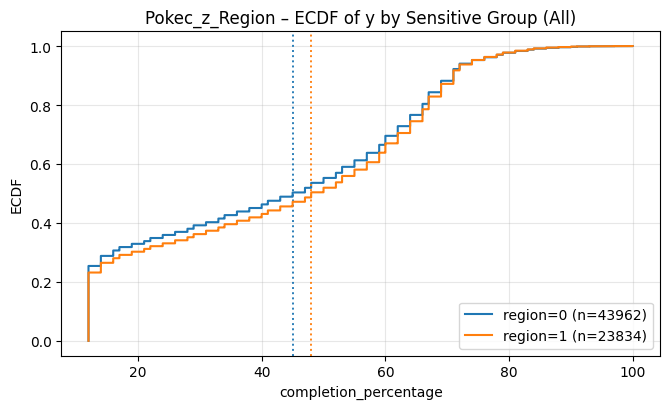

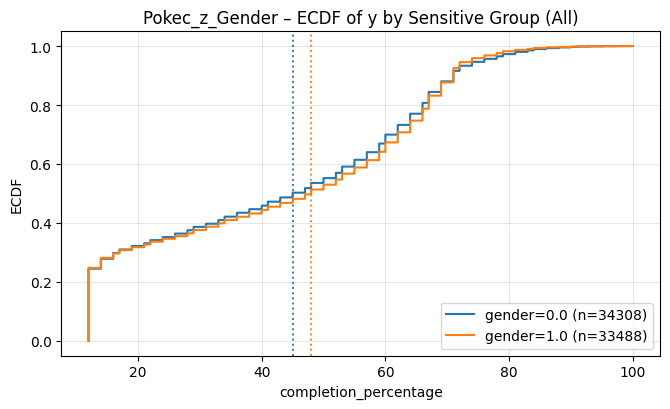

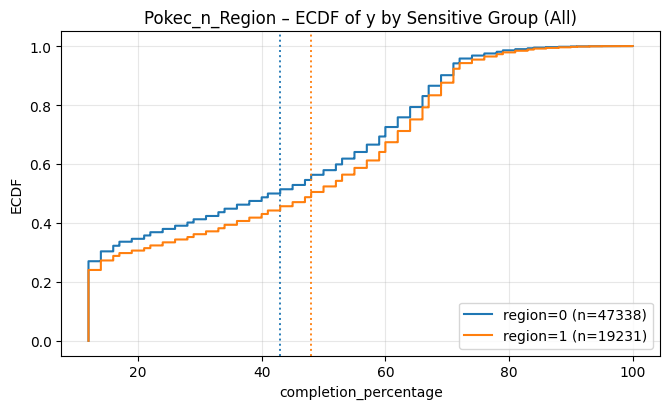

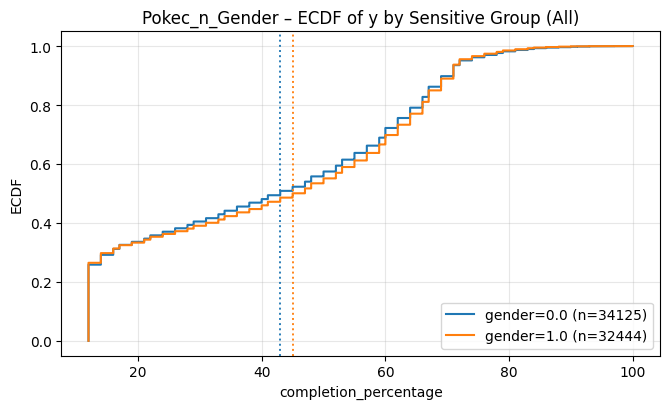

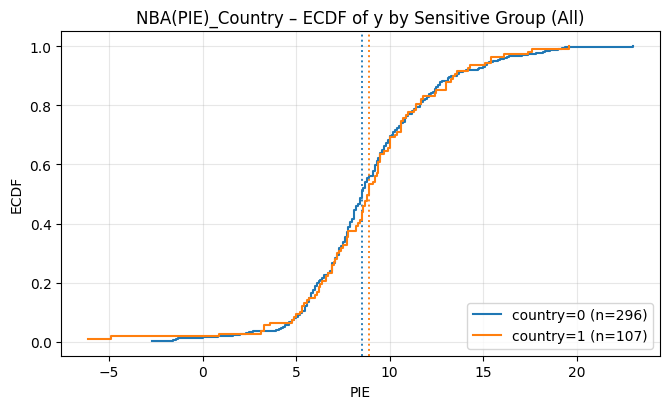

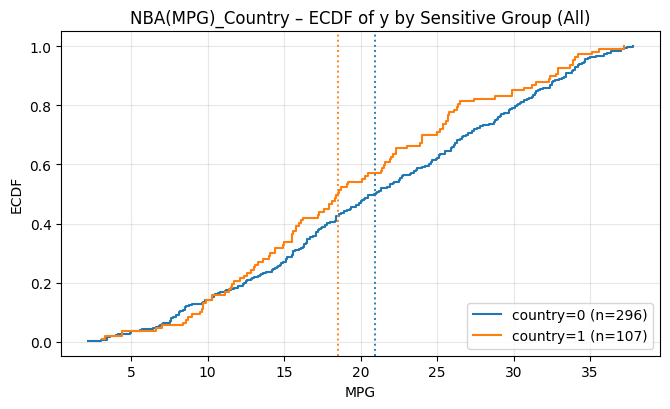

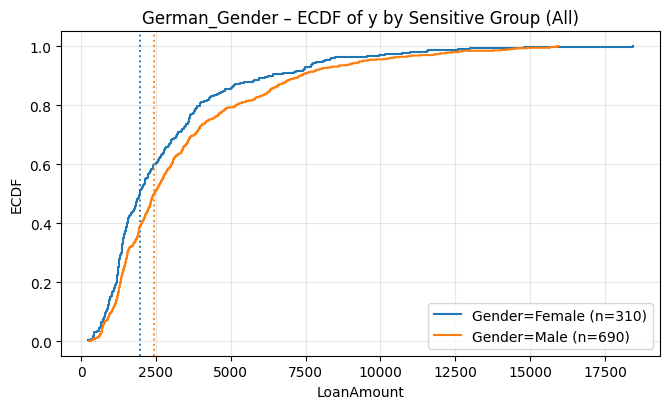

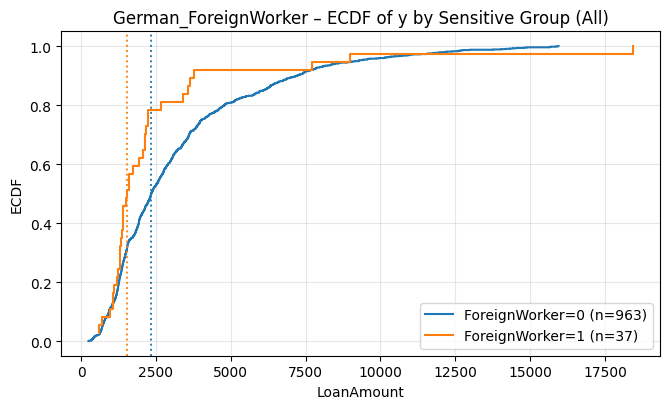

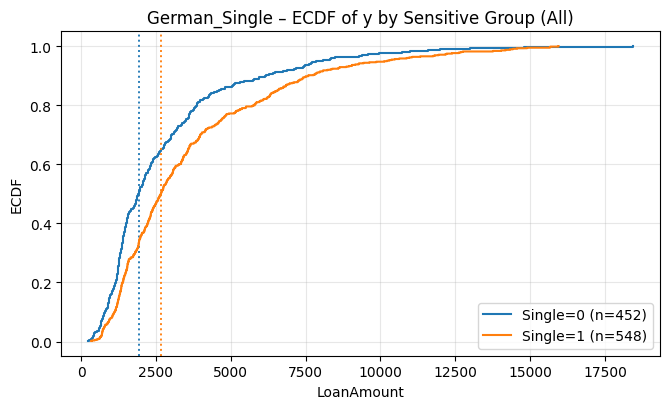

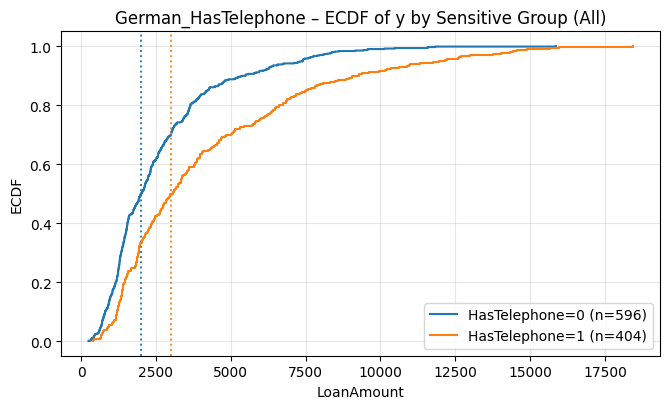

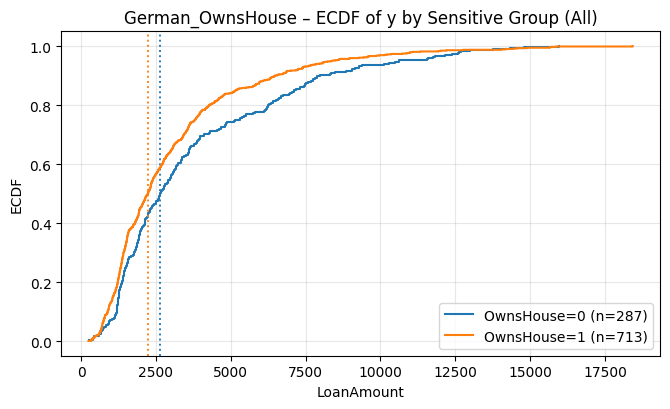

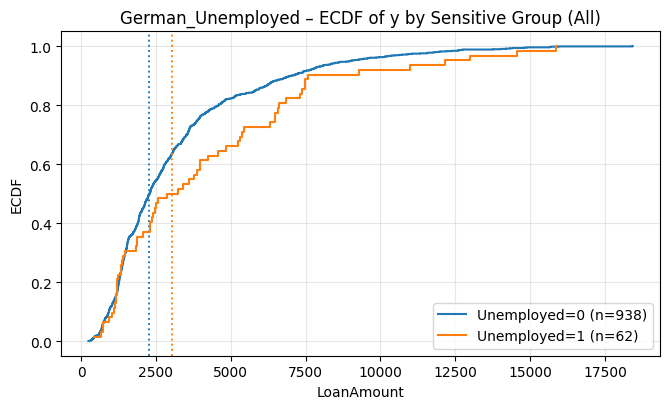

In [38]:
def _ecdf(values: np.ndarray):
    x = np.sort(values)
    n = len(x)
    y = np.arange(1, n + 1) / n
    return x, y

def plot_y_ecdf_with_group_vlines(
    pack,
    split="all",          # "all" | "train" | "val" | "test"
    min_samples=20,
    vlines=("median",),   # ("mean","median","iqr") 중 선택. 기본은 median만.
):
    df   = pack["df"]
    cfg  = pack["cfg"]
    data = pack["data"]

    name  = cfg.get("dn", "")
    y_col = cfg["predict_attr"]
    s_col = cfg["sens_attr"]

    if y_col not in df.columns:
        print(f"[SKIP] {name}: y column '{y_col}' not in df")
        return
    if s_col not in df.columns:
        print(f"[SKIP] {name}: sensitive column '{s_col}' not in df")
        return

    # split 인덱싱
    if split == "all":
        df_s = df
        split_tag = "All"
    else:
        idx_name = f"idx_{split}"
        if not hasattr(data, idx_name):
            print(f"[SKIP] {name}: data has no {idx_name} (cannot split='{split}')")
            return
        idx = getattr(data, idx_name)
        idx = idx.detach().cpu().numpy() if hasattr(idx, "detach") else np.asarray(idx)
        df_s = df.iloc[idx]
        split_tag = split.capitalize()

    # 결측 제거 + 타입 정리
    tmp = df_s[[y_col, s_col]].dropna().copy()
    tmp[y_col] = pd.to_numeric(tmp[y_col], errors="coerce")
    tmp = tmp.dropna(subset=[y_col, s_col])

    if len(tmp) == 0:
        print(f"[SKIP] {name}: no valid rows after cleaning")
        return

    groups = sorted(tmp[s_col].unique())

    fig, ax = plt.subplots(figsize=(6.8, 4.2))

    for g in groups:
        vals = tmp.loc[tmp[s_col] == g, y_col].to_numpy(dtype=float)
        n = len(vals)
        if n < min_samples:
            print(f"[SKIP] {name} | {s_col}={g} (n={n})")
            continue

        x, y = _ecdf(vals)
        ax.step(x, y, where="post", label=f"{s_col}={g} (n={n})")

        # 방금 그린 ECDF 선 색으로 수직선 찍기
        color = ax.lines[-1].get_color()

        if "mean" in vlines:
            ax.axvline(np.mean(vals), linestyle="--", linewidth=1, alpha=0.9, color=color)

        if "median" in vlines:
            ax.axvline(np.median(vals), linestyle=":", linewidth=1.4, alpha=0.95, color=color)

        if "iqr" in vlines:
            q25, q75 = np.quantile(vals, [0.25, 0.75])
            ax.axvline(q25, linestyle="-.", linewidth=1, alpha=0.7, color=color)
            ax.axvline(q75, linestyle="-.", linewidth=1, alpha=0.7, color=color)

    ax.set_xlabel(y_col)
    ax.set_ylabel("ECDF")
    ax.set_title(f"{name} – ECDF of y by Sensitive Group ({split_tag})")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

for ds in datasets:
    plot_y_ecdf_with_group_vlines(dt_dict[ds], split="all", vlines=("median",))


### 모델

In [40]:
def str2bool(v):
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Unsupported value encountered.')

def feature_norm(features):
    min_values = features.min(axis=0)[0]
    max_values = features.max(axis=0)[0]
    return 2*(features - min_values).div(max_values-min_values) - 1

def get_sen(sens, idx_sens_train):
    num_classes = 2  # binary sensitive attribute assumed
    one_hot = F.one_hot(sens.long(), num_classes=num_classes).float()  # (N, 2)

    # training 노드에 대해서만 정규화
    group_sums = one_hot[idx_sens_train].sum(dim=0, keepdim=True)  # (1, 2)
    group_sums[group_sums == 0] = 1  # 0으로 나누는 것 방지

    one_hot[idx_sens_train] = one_hot[idx_sens_train] / group_sums  # group-normalized

    return one_hot  # shape: (N, 2)

def quantile_loss(y_true, y_pred, tau=0.9):
    error = y_true - y_pred
    return torch.mean(torch.max(tau * error, (tau - 1) * error))

def normalize_scipy(mx):
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -0.5).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    mx = r_mat_inv.dot(mx).dot(r_mat_inv)
    return mx

def binarize(A_debiased, adj_ori, threshold_proportion):
    the_con1 = (A_debiased - adj_ori).A
    the_con1 = np.where(the_con1 > np.max(the_con1) * threshold_proportion, 1 + the_con1 * 0, the_con1)
    the_con1 = np.where(the_con1 < np.min(the_con1) * threshold_proportion, -1 + the_con1 * 0, the_con1)
    the_con1 = np.where(np.abs(the_con1) == 1, the_con1, the_con1 * 0)
    A_debiased = adj_ori + sp.coo_matrix(the_con1)
    assert A_debiased.max() == 1
    assert A_debiased.min() == 0
    A_debiased = normalize_scipy(A_debiased)
    return A_debiased

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)


In [41]:
# QpiGNN
class GQNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, dual_output=True, fixed_margin=None):
        super().__init__()
        self.dual_output = dual_output
        self.fixed_margin = fixed_margin
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        if dual_output:
            self.fc_pred = torch.nn.Linear(hidden_dim, 1)
            if fixed_margin is None:
                self.fc_diff = torch.nn.Linear(hidden_dim, 1)
        else:
            self.fc_low = torch.nn.Linear(hidden_dim, 1)
            self.fc_upper = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        
        if self.dual_output:
            preds = self.fc_pred(x)
            
            if self.fixed_margin is not None:
                diffs = torch.ones_like(preds) * self.fixed_margin
            else:
                diffs = torch.sigmoid(self.fc_diff(x))
                
            pred_low, pred_upper = preds - diffs, preds + diffs
            
            return pred_low, pred_upper
        
        else:
            pred_low = self.fc_low(x)
            pred_upper = self.fc_upper(x)
            
            return pred_low, pred_upper
         
class GQNNLoss(nn.Module):
    def __init__(self, target_coverage=0.9, lambda_factor=0.1):
        super().__init__()
        self.target_coverage = target_coverage
        self.lf = lambda_factor

    def forward(self, preds_low, preds_upper, target):
        # 폭 계산
        diffs = (preds_upper - preds_low) / 2
        width_loss = self.lf * 2 * diffs.mean()

        # 커버리지 밖 위반 거리 계산
        below_violation = torch.relu(preds_low - target)   # y_i < lower
        above_violation = torch.relu(target - preds_upper) # y_i > upper
        total_violation = below_violation + above_violation

        # 위반된 샘플만 선택
        is_violated = (target < preds_low) | (target > preds_upper)
        violation_count = is_violated.float().sum()

        # 평균 위반 거리 (구간 밖 샘플에 대해만)
        if violation_count > 0:
            mean_violation = (total_violation * is_violated.float()).sum() / violation_count
        else:
            mean_violation = torch.tensor(0.0, device=target.device)

        covered = (preds_low <= target) & (target <= preds_upper)
        current_coverage = covered.float().mean()
        coverage_penalty = (self.target_coverage - current_coverage) ** 2

        return mean_violation + coverage_penalty + width_loss

# 수정 버전 FnRGNN
class GroupWiseNorm(nn.Module):
    def __init__(self):
        super(GroupWiseNorm, self).__init__()

    def forward(self, pred, sensitive_attr):
        # 민감 속성 그룹 간 분포가 다르다는 것은 bias가 있을 수 있다는 뜻이고, 이를 fairness 관점에서 줄이려는 것
        # 두 그룹의 representation의 분포를 가깝게
        mask_0 = (sensitive_attr == 0).squeeze()
        mask_1 = (sensitive_attr == 1).squeeze()
        pred_0 = pred[mask_0]
        pred_1 = pred[mask_1]

        zero = torch.tensor(0.0, device=pred.device)
        mean_diff = torch.abs(pred_0.mean() - pred_1.mean()) if pred_0.numel() > 0 and pred_1.numel() > 0 else zero
        var_diff = torch.abs(pred_0.var() - pred_1.var()) if pred_0.numel() > 0 and pred_1.numel() > 0 else zero
        
        return mean_diff + var_diff

class FnRGNN(nn.Module):
    def __init__(self, nfeat, hidden_dim, dropout, lm, ld, mmd_sample, lr, weight_decay, fairness_mode="uniform"):
        super(FnRGNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.lambda2 = lm
        self.lambda_dist = ld
        self.mmd_sample_size = mmd_sample
        self.fairness_mode = fairness_mode

        self.gcn1 = GCNConv(nfeat, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 1)

        self.group_norm = GroupWiseNorm()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def compute_mmd(self, h, sensitive_attr):
        # adversarial loss 없이도 직접적인 distance loss로 추가 가능
        # 단점: 해당 속성이 뭔지 명확할 때만 쓸 수 있음. 즉, 민감 속성 라벨이 없는 경우에는 직접 쓰기 힘듦
        # 두 확률 분포 간의 평균 임베딩 차이를 측정해 그룹 간 분포가 비슷해지도록 압력
        # In-processing fairness constraints in model training: 목적: 모델이 학습 중에 민감 그룹 간 차이를 덜 반영하도록 압력 주고 싶다
        # 필요한 이유: fairness constraint를 soft하게 걸 수 있는 방법이 필요할 때, MMD는 differentiable하면서도 샘플 기반이라 유연하고 강력한 도구가 됨.
        mask_0 = (sensitive_attr == 0).squeeze()
        mask_1 = (sensitive_attr == 1).squeeze()
        h_0 = h[mask_0]
        h_1 = h[mask_1]
        
        if h_0.size(0) > self.mmd_sample_size:
            idx_0 = torch.randperm(h_0.size(0), device=h.device)[:self.mmd_sample_size]
            h_0 = h_0[idx_0]
        if h_1.size(0) > self.mmd_sample_size:
            idx_1 = torch.randperm(h_1.size(0), device=h.device)[:self.mmd_sample_size]
            h_1 = h_1[idx_1]
        
        if h_0.numel() == 0 or h_1.numel() == 0:
            return torch.tensor(0.0, device=h.device)
        
        sigma = 1.0
        dist_xx = torch.cdist(h_0, h_0) ** 2
        dist_yy = torch.cdist(h_1, h_1) ** 2
        dist_xy = torch.cdist(h_0, h_1) ** 2
        xx = torch.exp(-dist_xx / (2 * sigma**2)).mean()
        yy = torch.exp(-dist_yy / (2 * sigma**2)).mean()
        xy = torch.exp(-dist_xy / (2 * sigma**2)).mean()

        return xx + yy - 2 * xy

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        sensitive_attr = data.sensitive_attr

        num_edges = edge_index.size(1)
        edge_weight = torch.ones(num_edges, device=x.device)
        sen_diff = sensitive_attr[edge_index[0]] != sensitive_attr[edge_index[1]]
        edge_weight[sen_diff] *= 0.5  # 민감 속성 다른 엣지 가중치 감소

        h = self.gcn1(x, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, self.dropout, training=self.training)
        h = self.gcn2(h, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, self.dropout, training=self.training)
        y = self.classifier(h)
        return y, h

    def optimize(self, data):
        labels, idx_train, sensitive_attr = (data.y, data.idx_train, data.sensitive_attr)
        self.train()
        self.optimizer.zero_grad()

        y, h = self.forward(data)

        # task는 train만
        task_loss = self.criterion(y[idx_train], labels[idx_train].unsqueeze(1).float())

        # fairness도 train만
        if self.fairness_mode == "uniform":
            idx_fair = idx_train
        elif self.fairness_mode == "low_degree":
            # degree 기반 conditional
            edge_index = data.edge_index
            deg = torch.bincount(edge_index[0], minlength=data.x.size(0))
            deg_train = deg[idx_train]

            # 하위 30% degree 노드는 제외: degree가 낮은(어려운) 노드 30%는 fairness에서 제외
            thr = torch.quantile(deg_train.float(), 0.3)
            idx_fair = idx_train[deg_train > thr]
        elif self.fairness_mode == "boundary":
            # boundary score 기반 conditional
            edge_index = data.edge_index
            sens = sensitive_attr

            nei_diff = (sens[edge_index[0]] != sens[edge_index[1]]).float()
            boundary_score = torch.zeros(data.x.size(0), device=h.device)
            boundary_score.index_add_(0, edge_index[0], nei_diff)

            b_train = boundary_score[idx_train]
            thr = torch.quantile(b_train, 0.7)  # 상위 boundary 제외: boundary_score 상위 30%를 찾는 것
            # 이웃이 많이 섞여 있어서 헷갈리는 노드들은 공정성 판단에서 잠시 제외
            idx_fair = idx_train[b_train < thr]
        elif self.fairness_mode == "norm_boundary":
            # normalized boundary score 기반 conditional
            edge_index = data.edge_index
            sens = sensitive_attr

            src, dst = edge_index[0], edge_index[1]
            nei_diff = (sens[src] != sens[dst]).float()

            # 노드별 different-neighbor count (분자)
            diff_cnt = torch.zeros(data.x.size(0), device=sens.device)
            diff_cnt.index_add_(0, src, nei_diff)

            # 노드별 degree (분모) - src 기준으로 카운트 (현재 구현과 동일한 기준)
            deg = torch.bincount(src, minlength=data.x.size(0)).float().to(sens.device)

            # 0-degree 방지 (train 노드에 0-degree가 있을 수 있으면 안전장치)
            deg = deg.clamp(min=1.0)
            boundary_score = diff_cnt / deg  # [0, 1]

            b_train = boundary_score[idx_train]
            thr = torch.quantile(b_train, 0.7)  # 상위 30% 제외 (기준은 그대로)
            idx_fair = idx_train[b_train < thr]
        else:
            raise ValueError(f"Unknown fairness_mode: {self.fairness_mode}")

        # fairness loss
        if idx_fair.numel() > 0:
            mmd_loss = self.compute_mmd(h[idx_fair], sensitive_attr[idx_fair])
            dist_loss = self.group_norm(y[idx_fair], sensitive_attr[idx_fair])
        else:
            zero = torch.tensor(0.0, device=h.device)
            mmd_loss = zero
            dist_loss = zero

        total_loss = task_loss + self.lambda2 * mmd_loss + self.lambda_dist * dist_loss
        total_loss.backward()
        self.optimizer.step()
        return total_loss.item()


### Uncertainty

In [217]:
def set_seed(seed=1127):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_split_indices(data, split="train"):
    """
    다양한 데이터셋 포맷을 흡수:
    - idx_train / idx_val / idx_test (LongTensor of indices)
    - train_mask / val_mask / test_mask (Bool mask)
    """
    if split in ["train","val","test"]:
        idx_name = f"idx_{split}"
        mask_name = f"{split}_mask"
    else:
        raise ValueError("split must be one of train/val/test")

    if hasattr(data, idx_name):
        idx = getattr(data, idx_name)
        if idx is None: return None
        return idx.detach().cpu() if hasattr(idx, "detach") else torch.as_tensor(idx)

    if hasattr(data, mask_name):
        m = getattr(data, mask_name)
        if m is None: return None
        m = m.detach().cpu() if hasattr(m, "detach") else torch.as_tensor(m)
        return torch.where(m)[0]

    return None


In [218]:
# 핵심: train idx로 loss 학습하고, 전체 노드에 대해 지표를 저장한다.
class GQNN(torch.nn.Module):
    """
    Graph Quantile-like interval predictor:
      outputs [L_i, U_i] per node.
    """
    def __init__(self, in_dim, hidden_dim, dual_output=True, fixed_margin=None, diff_act="softplus"):
        super().__init__()
        self.dual_output = dual_output
        self.fixed_margin = fixed_margin
        self.diff_act = diff_act

        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        if dual_output:
            self.fc_pred = torch.nn.Linear(hidden_dim, 1)
            if fixed_margin is None:
                self.fc_diff = torch.nn.Linear(hidden_dim, 1)
        else:
            self.fc_low = torch.nn.Linear(hidden_dim, 1)
            self.fc_upper = torch.nn.Linear(hidden_dim, 1)

    def _activate_diff(self, raw):
        if self.diff_act == "sigmoid":
            return torch.sigmoid(raw)  # (0,1)
        # softplus: (0, inf)
        return F.softplus(raw)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))

        if self.dual_output:
            preds = self.fc_pred(h)

            if self.fixed_margin is not None:
                diffs = torch.ones_like(preds) * float(self.fixed_margin)
            else:
                diffs = self._activate_diff(self.fc_diff(h))

            pred_low  = preds - diffs
            pred_upper = preds + diffs
            return pred_low, pred_upper
        else:
            pred_low = self.fc_low(h)
            pred_upper = self.fc_upper(h)
            # interval ordering 보장(혹시 뒤집히면 교정)
            lo = torch.minimum(pred_low, pred_upper)
            up = torch.maximum(pred_low, pred_upper)
            return lo, up

class GQNNLoss(nn.Module):
    def __init__(self, target_coverage=0.9, lambda_factor=0.1):
        super().__init__()
        self.target_coverage = float(target_coverage)
        self.lf = float(lambda_factor)

    def forward(self, preds_low, preds_upper, target):
        # width penalty: 폭을 줄이도록
        diffs = (preds_upper - preds_low) / 2.0
        width_loss = self.lf * 2.0 * diffs.mean()

        below_violation = torch.relu(preds_low - target)   # y < lower
        above_violation = torch.relu(target - preds_upper) # y > upper
        total_violation = below_violation + above_violation

        is_violated = (target < preds_low) | (target > preds_upper)
        violation_count = is_violated.float().sum()

        if violation_count > 0:
            mean_violation = (total_violation * is_violated.float()).sum() / violation_count
        else:
            mean_violation = torch.tensor(0.0, device=target.device)

        covered = (preds_low <= target) & (target <= preds_upper)
        current_coverage = covered.float().mean()
        coverage_penalty = (self.target_coverage - current_coverage) ** 2

        return mean_violation + coverage_penalty + width_loss

@torch.no_grad()
def compute_node_uncertainty(pred_low, pred_upper, y_true):
    L = pred_low.view(-1)
    U = pred_upper.view(-1)
    y = y_true.view(-1)

    width = (U - L).clamp_min(0.0)
    covered = ((L <= y) & (y <= U)).float()

    below = torch.relu(L - y)
    above = torch.relu(y - U)
    violation = below + above

    # 정규화(데이터셋 스케일 다를 때 비교용)
    y_scale = torch.std(y).clamp_min(1e-6)
    width_norm = width / y_scale
    violation_norm = violation / y_scale

    return {
        "L": L.detach().cpu().numpy(),
        "U": U.detach().cpu().numpy(),
        "width": width.detach().cpu().numpy(),
        "covered": covered.detach().cpu().numpy(),
        "violation": violation.detach().cpu().numpy(),
        "width_norm": width_norm.detach().cpu().numpy(),
        "violation_norm": violation_norm.detach().cpu().numpy(),
    }

def train_gqnn_one_dataset(
    data,
    in_dim,
    hidden_dim=128,
    target_coverage=0.9,
    lambda_factor=0.05,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=200,
    fixed_margin=None,
    diff_act="softplus",
    device=None,
    verbose=False,
):
    device = device or get_device()
    model = GQNN(in_dim, hidden_dim, dual_output=True, fixed_margin=fixed_margin, diff_act=diff_act).to(device)
    loss_fn = GQNNLoss(target_coverage=target_coverage, lambda_factor=lambda_factor).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    data = data.to(device)
    x = data.x
    edge_index = data.edge_index
    y = data.y.view(-1, 1).float()

    idx_train = get_split_indices(data, "train")
    if idx_train is None:
        # German처럼 split 없으면 전체로 학습(권장X이지만 분석용)
        idx_train = torch.arange(x.size(0), device="cpu")

    idx_train = idx_train.to(device)

    for ep in range(1, epochs + 1):
        model.train()
        opt.zero_grad()

        L, U = model(x, edge_index)
        loss = loss_fn(L[idx_train], U[idx_train], y[idx_train])

        loss.backward()
        opt.step()

        if verbose and (ep % 50 == 0 or ep == 1):
            # train coverage 참고 출력
            with torch.no_grad():
                covered = ((L[idx_train] <= y[idx_train]) & (y[idx_train] <= U[idx_train])).float().mean().item()
                mean_w = (U[idx_train] - L[idx_train]).mean().item()
            print(f"Epoch {ep:4d} | loss={loss.item():.4f} | train_cov={covered:.3f} | train_width={mean_w:.3f}")

    # 전체 노드 uncertainty 계산
    model.eval()
    with torch.no_grad():
        L, U = model(x, edge_index)
    unc = compute_node_uncertainty(L, U, y)

    return model, unc


In [219]:
# degree
def compute_degree(edge_index, num_nodes):
    src = edge_index[0].detach().cpu().numpy()
    deg = np.bincount(src, minlength=num_nodes)
    return deg

# 불확실성 높은 노드끼리 모여 있는지
def neighbor_high_rate(edge_index, high_mask, num_nodes):
    src = edge_index[0].detach().cpu().numpy()
    dst = edge_index[1].detach().cpu().numpy()
    high = high_mask.astype(np.int32)

    deg = np.bincount(src, minlength=num_nodes)
    high_nbr = np.bincount(src, weights=high[dst], minlength=num_nodes)
    rate = high_nbr / np.maximum(deg, 1)
    return rate, deg

# 민감속성 이웃 혼합도
def neighbor_high_rate(edge_index, high_mask, num_nodes):
    src = edge_index[0].detach().cpu().numpy()
    dst = edge_index[1].detach().cpu().numpy()
    high = high_mask.astype(np.int32)

    deg = np.bincount(src, minlength=num_nodes)
    high_nbr = np.bincount(src, weights=high[dst], minlength=num_nodes)
    rate = high_nbr / np.maximum(deg, 1)
    return rate, deg


In [222]:
def summarize_uncertainty_observations(pack, unc, top_q=0.9):
    data = pack["data"]
    df = pack["df"]
    cfg = pack["cfg"]
    name = cfg.get("dn", "")

    N = data.num_nodes
    deg = compute_degree(data.edge_index, N)

    width = unc["width_norm"]  # 스케일 정규화 버전 권장
    viol  = unc["violation_norm"]
    covered = unc["covered"]

    thr = np.quantile(width, top_q)
    high = width >= thr

    nh_rate, _ = neighbor_high_rate(data.edge_index, high, N)
    high_cluster_score = np.mean(nh_rate[high])  # high 노드들의 이웃-high 비율 평균

    # degree-uncertainty 상관(스피어만)
    def spearman(a,b):
        ra = pd.Series(a).rank().to_numpy()
        rb = pd.Series(b).rank().to_numpy()
        return np.corrcoef(ra, rb)[0,1]

    corr_deg_w = spearman(deg, width)
    corr_deg_v = spearman(deg, viol)

    # 그룹별 fairness-friendly uncertainty(있으면)
    s_col = cfg["sens_attr"]
    group_stats = None
    if s_col in df.columns:
        s = df[s_col].to_numpy()
        # 그룹별 평균 width/violation/coverage
        group_stats = {}
        for g in sorted(pd.unique(s[~pd.isna(s)])):
            idx = (s == g)
            group_stats[g] = {
                "n": int(idx.sum()),
                "mean_width": float(np.mean(width[idx])),
                "mean_violation": float(np.mean(viol[idx])),
                "coverage": float(np.mean(covered[idx])),
                "high_width_rate": float(np.mean(high[idx])),
            }

    out = {
        "dataset": name,
        "N": N,
        "width_topq": top_q,
        "high_width_threshold(width_norm)": float(thr),
        "mean_width": float(np.mean(width)),
        "mean_violation": float(np.mean(viol)),
        "coverage_overall": float(np.mean(covered)),
        "corr(deg,width)": float(corr_deg_w),
        "corr(deg,violation)": float(corr_deg_v),
        "high_width_neighbor_high_rate": float(high_cluster_score),
        "group_stats": group_stats,
    }
    return out

def run_uncertainty_pipeline(dt_dict, datasets, hidden_dim=64, epochs=500,
                             target_coverage=0.9, lambda_factor=0.5,
                             seed=1127, verbose=False,
                             top_q=0.9,
                             beta=3.0,
                             use_relative_violation=True,
                             eps=1e-12):
    set_seed(seed)
    device = get_device()
    reports = []

    def _as_1d_float_tensor(x, N=None, name="vector"):
        if isinstance(x, torch.Tensor):
            t = x.detach().cpu()
        else:
            t = torch.as_tensor(x).detach().cpu()
        t = t.reshape(-1).float()
        if N is not None and t.numel() != N:
            raise ValueError(f"{name} length mismatch: got {t.numel()}, expected {N}")
        return t

    def _norm01_torch(v):
        v = v.float()
        return (v - v.min()) / (v.max() - v.min() + eps)

    def _extract_1d_vector(container, keys, N=None):
        # dict
        if isinstance(container, dict):
            for k in keys:
                if k in container:
                    v = container[k]
                    try:
                        t = _as_1d_float_tensor(v, N=N, name=k)
                        return t, k
                    except Exception:
                        pass

            # fallback
            for k, v in container.items():
                try:
                    t = _as_1d_float_tensor(v, N=N, name=k)
                except Exception:
                    continue
                if any(tk in k.lower() for tk in ["width", "unc", "lo", "hi", "lower", "upper", "y", "target"]):
                    return t, k

        # tuple/list
        if isinstance(container, (list, tuple)):
            for idx, item in enumerate(container):
                try:
                    t = _as_1d_float_tensor(item, N=N, name=f"tuple[{idx}]")
                    return t, f"tuple[{idx}]"
                except Exception:
                    continue

        # object attrs
        if not isinstance(container, (dict, list, tuple)):
            for k in keys:
                if hasattr(container, k):
                    try:
                        t = _as_1d_float_tensor(getattr(container, k), N=N, name=k)
                        return t, k
                    except Exception:
                        pass

        raise KeyError("1D 벡터를 찾지 못했습니다. unc 구조/키를 확인하세요.")

    def _extract_bounds_and_y(data, unc, N):
        # y_true는 data.y가 최우선
        if hasattr(data, "y") and data.y is not None:
            y_true = _as_1d_float_tensor(data.y, N=N, name="data.y")
        else:
            y_true, _ = _extract_1d_vector(unc, ["y", "y_true", "target", "labels", "label"], N=N)

        lo_keys = ["q_lo", "q_low", "q_lower", "lower", "lo", "y_lo", "pred_lo", "pi_lo", "interval_lo"]
        hi_keys = ["q_hi", "q_high", "q_upper", "upper", "hi", "y_hi", "pred_hi", "pi_hi", "interval_hi"]

        q_lo, lo_key = _extract_1d_vector(unc, lo_keys, N=N)
        q_hi, hi_key = _extract_1d_vector(unc, hi_keys, N=N)

        return q_lo, q_hi, y_true, (lo_key, hi_key)

    def _composite_uncertainty(width_vec, q_lo, q_hi, y_true):
        # width normalize
        w = _norm01_torch(width_vec)

        # violation magnitude (distance outside interval)
        below = (q_lo - y_true).clamp(min=0.0)
        above = (y_true - q_hi).clamp(min=0.0)
        m_raw = torch.maximum(below, above)

        if use_relative_violation:
            denom = (q_hi - q_lo).abs().clamp(min=eps)
            m_raw = m_raw / denom

        m = _norm01_torch(m_raw)

        # ✅ 추천 정의: u = w * (1 + beta*m)
        u = w * (1.0 + beta * m)
        return u, w, m, m_raw

    for ds in datasets:
        pack = dt_dict[ds]
        data = pack["data"]
        in_dim = data.x.size(1)
        N = data.num_nodes

        model, unc = train_gqnn_one_dataset(
            data=data,
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            target_coverage=target_coverage,
            lambda_factor=lambda_factor,
            epochs=epochs,
            device=device,
            verbose=verbose,
        )

        pack["gqnn_model"] = model
        pack["uncertainty"] = unc

        rep = summarize_uncertainty_observations(pack, unc, top_q=top_q)

        # 네트워크 시각화용
        rep["edge_index"] = data.edge_index.detach().cpu()

        # degree
        try:
            rep["degree"] = torch.bincount(data.edge_index[0], minlength=N).detach().cpu()
        except Exception:
            pass

        # width vector
        width_vec, width_key = _extract_1d_vector(
            unc,
            keys=["node_width_norm", "width_norm", "node_width", "width",
                  "node_uncertainty", "uncertainty", "unc", "u"],
            N=N
        )
        rep["node_width"] = width_vec.detach().cpu()
        rep["node_width_key"] = width_key

        # composite (가능하면)
        try:
            q_lo, q_hi, y_true, (lo_key, hi_key) = _extract_bounds_and_y(data, unc, N=N)
            u_comp, w01, m01, m_raw = _composite_uncertainty(width_vec, q_lo, q_hi, y_true)

            rep["y_true"] = y_true.detach().cpu()
            rep["q_lo"] = q_lo.detach().cpu()
            rep["q_hi"] = q_hi.detach().cpu()
            rep["q_bounds_key"] = (lo_key, hi_key)

            rep["node_violation_magnitude_raw"] = m_raw.detach().cpu()
            rep["node_violation_magnitude_norm01"] = m01.detach().cpu()
            rep["node_width_norm01"] = w01.detach().cpu()

            rep["node_uncertainty"] = u_comp.detach().cpu()
            rep["node_uncertainty_key"] = f"composite: norm({width_key})*(1+beta*norm(viol_mag)), beta={beta}, rel={use_relative_violation}"

        except Exception as e:
            # bounds 못 찾으면 width-only로 fallback
            rep["node_uncertainty"] = width_vec.detach().cpu()
            rep["node_uncertainty_key"] = f"fallback width-only: {width_key} (composite unavailable: {type(e).__name__})"

        reports.append(rep)

        print(
            f"[DONE] {rep['dataset']} | cov={rep['coverage_overall']:.3f} | "
            f"mean_w={rep['mean_width']:.3f} | mean_v={rep['mean_violation']:.3f} | "
            f"corr(deg,w)={rep['corr(deg,width)']:.3f} | hotspot={rep['high_width_neighbor_high_rate']:.3f} | "
            f"node_u={rep.get('node_uncertainty_key','?')}"
        )

    return reports


In [223]:
dts = ['region_job_r', 'region_job_g', 'region_job_2_r', 'region_job_2_g']
reports_pokec = run_uncertainty_pipeline(dt_dict, datasets=dts, epochs=500, target_coverage=0.9, lambda_factor=0.45, verbose=False)

dts = ['nba_p', 'nba_m']
reports_nba = run_uncertainty_pipeline(dt_dict, dts, epochs=500, target_coverage=0.9, lambda_factor=0.1, verbose=False)

dts = ['german_g', 'german_f', 'german_s', 'german_t', 'german_h', 'german_e']
reports_german = run_uncertainty_pipeline(dt_dict, dts, epochs=500, target_coverage=0.9, lambda_factor=0.3, verbose=False)


[DONE] region_job_r | cov=0.996 | mean_w=0.922 | mean_v=0.000 | corr(deg,w)=0.218 | hotspot=0.554 | node_u=composite: norm(width_norm)*(1+beta*norm(viol_mag)), beta=3.0, rel=True
[DONE] region_job_g | cov=0.997 | mean_w=0.996 | mean_v=0.000 | corr(deg,w)=0.259 | hotspot=0.532 | node_u=composite: norm(width_norm)*(1+beta*norm(viol_mag)), beta=3.0, rel=True
[DONE] region_job_2_r | cov=0.997 | mean_w=0.948 | mean_v=0.000 | corr(deg,w)=0.306 | hotspot=0.552 | node_u=composite: norm(width_norm)*(1+beta*norm(viol_mag)), beta=3.0, rel=True
[DONE] region_job_2_g | cov=0.996 | mean_w=0.953 | mean_v=0.000 | corr(deg,w)=0.342 | hotspot=0.502 | node_u=composite: norm(width_norm)*(1+beta*norm(viol_mag)), beta=3.0, rel=True
[DONE] nba_p | cov=0.893 | mean_w=1.234 | mean_v=0.043 | corr(deg,w)=-0.056 | hotspot=0.151 | node_u=composite: norm(width_norm)*(1+beta*norm(viol_mag)), beta=3.0, rel=True
[DONE] nba_m | cov=0.906 | mean_w=0.812 | mean_v=0.015 | corr(deg,w)=-0.222 | hotspot=0.214 | node_u=compos

In [ ]:
def reports_to_dataset_df(reports):
    rows = []
    for r in reports:
        rows.append({
            "dataset": r["dataset"],
            "N": r["N"],
            "width_topq": r["width_topq"],
            "high_width_threshold_width_norm": r["high_width_threshold(width_norm)"],
            "mean_width_norm": r["mean_width"],
            "mean_violation_norm": r["mean_violation"],
            "coverage_overall": r["coverage_overall"],
            "corr_deg_width": r["corr(deg,width)"],
            "corr_deg_violation": r["corr(deg,violation)"],
            "high_width_neighbor_high_rate": r["high_width_neighbor_high_rate"],
        })
    return pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)

def reports_to_group_df(reports):
    rows = []
    for r in reports:
        gs = r.get("group_stats", None)
        if not gs:
            continue
        for g, st in gs.items():
            rows.append({
                "dataset": r["dataset"],
                "group": g,
                "n_group": st["n"],
                "mean_width_norm": st["mean_width"],
                "mean_violation_norm": st["mean_violation"],
                "coverage": st["coverage"],
                "high_width_rate": st["high_width_rate"],
            })
    return pd.DataFrame(rows).sort_values(["dataset", "group"]).reset_index(drop=True)

def reports_to_group_gap_df(reports):
    rows = []
    for r in reports:
        gs = r.get("group_stats", None)
        if not gs or len(gs) < 2:
            continue

        # 그룹이 2개라고 가정(현재 네 데이터셋 설정상 대부분 2개)
        groups = list(gs.keys())
        g0, g1 = groups[0], groups[1]

        def gap(key):
            return float(gs[g1][key] - gs[g0][key])

        rows.append({
            "dataset": r["dataset"],
            "group0": g0,
            "group1": g1,
            "gap_mean_width_norm(g1-g0)": gap("mean_width"),
            "gap_coverage(g1-g0)": gap("coverage"),
            "gap_mean_violation_norm(g1-g0)": gap("mean_violation"),
            "gap_high_width_rate(g1-g0)": gap("high_width_rate"),
            "n0": gs[g0]["n"],
            "n1": gs[g1]["n"],
        })

    return pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)


In [107]:
# reports = reports_german.copy()

# dataset_df = reports_to_dataset_df(reports)
# group_df = reports_to_group_df(reports)
# gap_df = reports_to_group_gap_df(reports)

# print(dataset_df)
# print(group_df)
# print(gap_df)

In [267]:
def extract_main_uncertainty_table(reports):
    rows = []
    for r in reports:
        rows.append({
            "dataset": r["dataset"],
            "N": r["N"],
            "mean_width": r["mean_width"],
            "mean_violation": r["mean_violation"],
            "coverage_overall": r["coverage_overall"],
            "corr_deg_width": r["corr(deg,width)"],
            "corr_deg_violation": r["corr(deg,violation)"],
            "high_width_neighbor_high_rate": r["high_width_neighbor_high_rate"],
            "width_topq": r["width_topq"],
            "high_width_threshold": r["high_width_threshold(width_norm)"],
        })
    return pd.DataFrame(rows)

def extract_group_uncertainty_table(reports):
    rows = []
    for r in reports:
        dataset = r["dataset"]
        for group, stats in r["group_stats"].items():
            rows.append({
                "dataset": dataset,
                "group": group,
                "n": stats["n"],
                "mean_width": stats["mean_width"],
                "mean_violation": stats["mean_violation"],
                "coverage": stats["coverage"],
                "high_width_rate": stats["high_width_rate"],
            })
    return pd.DataFrame(rows)

def extract_group_gap_table(df_group):
    rows = []
    for dataset, sub in df_group.groupby("dataset"):
        if sub["group"].nunique() != 2:
            continue

        sub = sub.sort_values("group")
        g0 = sub.iloc[0]
        g1 = sub.iloc[1]

        rows.append({
            "dataset": dataset,
            "Δ mean_width": g1["mean_width"] - g0["mean_width"],
            "Δ mean_violation": g1["mean_violation"] - g0["mean_violation"],
            "Δ coverage": g1["coverage"] - g0["coverage"],
            "Δ high_width_rate": g1["high_width_rate"] - g0["high_width_rate"],
        })
    return pd.DataFrame(rows)

reports = reports_pokec + reports_nba + reports_german

df_main = extract_main_uncertainty_table(reports)
print(df_main)

df_group = extract_group_uncertainty_table(reports)
print(df_group)

df_gap = extract_group_gap_table(df_group)
print(df_gap)


           dataset      N  mean_width  mean_violation  coverage_overall  \
0     region_job_r  67796    0.921732        0.000343          0.995560   
1     region_job_g  67796    0.995811        0.000294          0.996784   
2   region_job_2_r  66569    0.948024        0.000337          0.996890   
3   region_job_2_g  66569    0.952654        0.000303          0.995899   
4            nba_p    403    1.233722        0.042874          0.893300   
5            nba_m    403    0.811503        0.015149          0.905707   
6         german_g   1000    2.120135        0.011142          0.909000   
7         german_f   1000    1.987587        0.024236          0.888000   
8         german_s   1000    2.093058        0.011899          0.880000   
9         german_t   1000    2.046425        0.016534          0.873000   
10        german_h   1000    2.156719        0.007250          0.882000   
11        german_e   1000    2.106102        0.013108          0.890000   

    corr_deg_width  corr

In [348]:
def make_abc_core_table(df_main, df_gap):
    # A: dataset-level 핵심
    a = df_main[[
        "dataset",
        "coverage_overall",
        "mean_width",
        "corr_deg_width",
        "mean_violation",
        "corr_deg_violation",
        "high_width_neighbor_high_rate",
    ]].copy()

    # C: group gap 핵심
    c = df_gap[[
        "dataset",
        "Δ mean_width",
        "Δ high_width_rate",
    ]].copy()

    # merge
    out = a.merge(c, on="dataset", how="left")

    # 보기 좋게 라운딩
    round_map = {
        "coverage_overall": 4,
        "mean_width": 4,
        "corr_deg_width": 3,
        "high_width_neighbor_high_rate": 3,
        "Δ mean_width": 4,
        "Δ high_width_rate": 4,
    }
    for col, d in round_map.items():
        if col in out:
            out[col] = out[col].round(d)

    # 정렬: 해석 우선순위
    out = out.sort_values(
        by=["coverage_overall", "high_width_neighbor_high_rate"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return out

core_table = make_abc_core_table(df_main, df_gap)
print(core_table)


           dataset  coverage_overall  mean_width  corr_deg_width  \
0         german_t            0.8730      2.0464           0.199   
1         german_s            0.8800      2.0931           0.117   
2         german_h            0.8820      2.1567           0.031   
3         german_f            0.8880      1.9876           0.096   
4         german_e            0.8900      2.1061           0.127   
5            nba_p            0.8933      1.2337          -0.056   
6            nba_m            0.9057      0.8115          -0.222   
7         german_g            0.9090      2.1201           0.121   
8     region_job_r            0.9956      0.9217           0.218   
9   region_job_2_g            0.9959      0.9527           0.342   
10    region_job_g            0.9968      0.9958           0.259   
11  region_job_2_r            0.9969      0.9480           0.306   

    mean_violation  corr_deg_violation  high_width_neighbor_high_rate  \
0         0.016534           -0.025420    

In [232]:
def plot_group_uncertainty_kde(rep, dt_dict, sens_key, title=None,
                               max_points=30000, seed=0,
                               bw_method="scott",  # 'scott' | 'silverman' | float
                               gridsize=400,
                               clip_quantile=(0.01, 0.99)):
    """
    KDE plot for group-wise composite uncertainty.
    - seaborn 없이 matplotlib로 그림
    - scipy 있으면 gaussian_kde 사용
    - 없으면 histogram smoothing 대체

    rep: report dict (rep["node_uncertainty"] 필요)
    sens_key: data에서 민감집단(2그룹) 벡터 키
    """
    rng = np.random.default_rng(seed)

    ds = rep["dataset"]
    if title is None:
        title = ds

    u = np.asarray(rep["node_uncertainty"], dtype=float).reshape(-1)
    N = len(u)

    data = dt_dict[ds]["data"]

    # group vector 가져오기 (PyG Data / dict 지원)
    if hasattr(data, "keys") and sens_key in list(data.keys()):
        g = data[sens_key]
    elif isinstance(data, dict) and sens_key in data:
        g = data[sens_key]
    elif hasattr(data, sens_key):
        g = getattr(data, sens_key)
    else:
        raise KeyError(f"[{ds}] sens_key='{sens_key}'를 data에서 못 찾음")

    g = np.asarray(g.detach().cpu().numpy() if hasattr(g, "detach") else np.asarray(g)).reshape(-1)

    if len(g) != N:
        raise ValueError(f"[{ds}] 길이 불일치: uncertainty N={N}, group N={len(g)} (key={sens_key})")

    # 유효 마스크
    mask = np.isfinite(u)
    u = u[mask]
    g = g[mask]

    # 샘플링(너무 크면)
    if len(u) > max_points:
        idx = rng.choice(len(u), size=max_points, replace=False)
        u = u[idx]
        g = g[idx]
        note = f"sample {max_points}"
    else:
        note = "all"

    # binary로 만들기: 유니크가 2개 초과면 빈도 상위 2개만
    vals, cnts = np.unique(g, return_counts=True)
    if len(vals) > 2:
        top2 = vals[np.argsort(-cnts)[:2]]
        keep = (g == top2[0]) | (g == top2[1])
        u = u[keep]
        g = g[keep]
        note += " | top-2 groups only"

    vals = np.unique(g)
    if len(vals) != 2:
        raise ValueError(f"[{ds}] binary group이 아님: unique={vals[:10]} (key={sens_key})")

    v0, v1 = vals[0], vals[1]
    u0 = u[g == v0]
    u1 = u[g == v1]

    # x축 범위(꼬리값 때문에 찌그러지는 거 방지)
    lo = np.quantile(u, clip_quantile[0])
    hi = np.quantile(u, clip_quantile[1])
    xs = np.linspace(lo, hi, gridsize)

    # --- KDE 계산 ---
    ys0 = ys1 = None
    used = None

    try:
        from scipy.stats import gaussian_kde
        kde0 = gaussian_kde(u0, bw_method=bw_method)
        kde1 = gaussian_kde(u1, bw_method=bw_method)
        ys0 = kde0(xs)
        ys1 = kde1(xs)
        used = "scipy gaussian_kde"
    except Exception:
        # fallback: histogram -> moving average smoothing
        used = "histogram smoothing (fallback)"
        bins = max(50, gridsize // 4)
        h0, edges = np.histogram(u0, bins=bins, range=(lo, hi), density=True)
        h1, _     = np.histogram(u1, bins=bins, range=(lo, hi), density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # 간단한 smoothing (moving average)
        def smooth(y, w=7):
            w = max(3, int(w))
            kernel = np.ones(w) / w
            return np.convolve(y, kernel, mode="same")

        h0s = smooth(h0, w=9)
        h1s = smooth(h1, w=9)

        # centers -> xs로 보간
        ys0 = np.interp(xs, centers, h0s)
        ys1 = np.interp(xs, centers, h1s)

    # --- Plot ---
    plt.figure(figsize=(6.6, 4.4))
    plt.plot(xs, ys0, label=f"group {v0} (n={len(u0)})")
    plt.plot(xs, ys1, label=f"group {v1} (n={len(u1)})")
    plt.xlabel("node uncertainty (composite)")
    plt.ylabel("density (KDE)")
    plt.title(f"{title} KDE by {note}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 요약(캡션용)
    def stats(a):
        return dict(mean=float(np.mean(a)), median=float(np.median(a)), p90=float(np.quantile(a, 0.9)))
    s0, s1 = stats(u0), stats(u1)
    print(f"[{ds}] key='{sens_key}' | mean gap={s1['mean']-s0['mean']:+.4f} | p90 gap={s1['p90']-s0['p90']:+.4f}")


[region_job_r] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


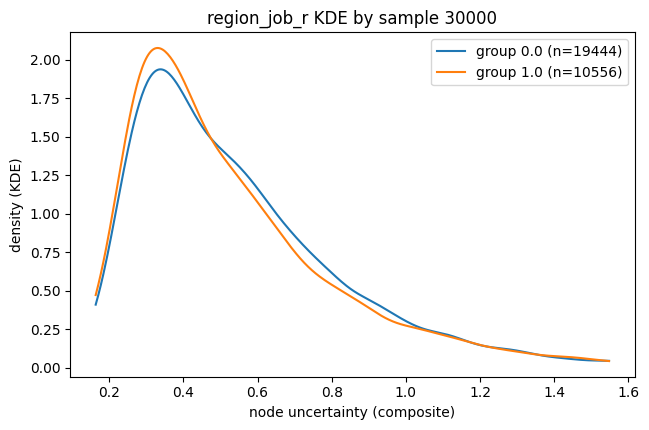

[region_job_r] key='sensitive_attr' | mean gap=-0.0157 | p90 gap=-0.0061
[region_job_g] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


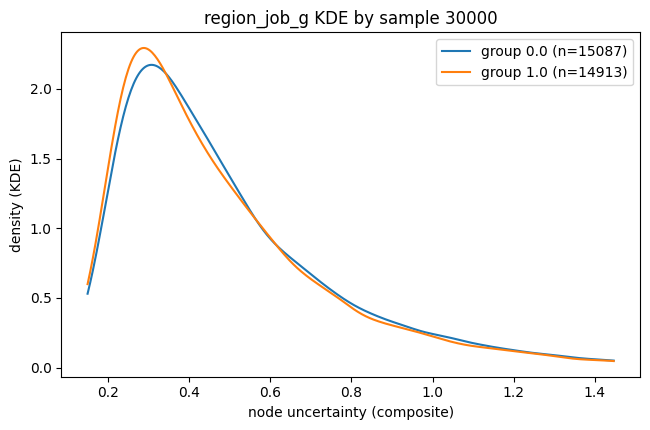

[region_job_g] key='sensitive_attr' | mean gap=-0.0139 | p90 gap=-0.0237
[region_job_2_r] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


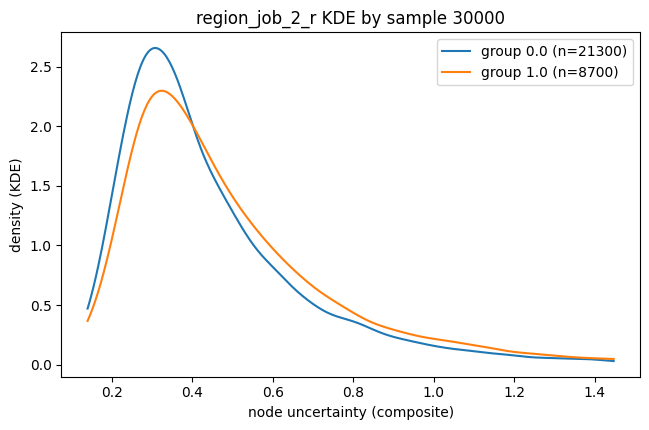

[region_job_2_r] key='sensitive_attr' | mean gap=+0.0458 | p90 gap=+0.0833
[region_job_2_g] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


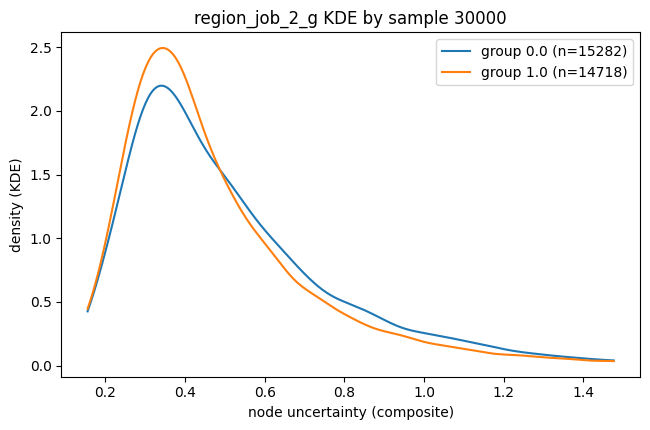

[region_job_2_g] key='sensitive_attr' | mean gap=-0.0350 | p90 gap=-0.0789
[nba_p] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


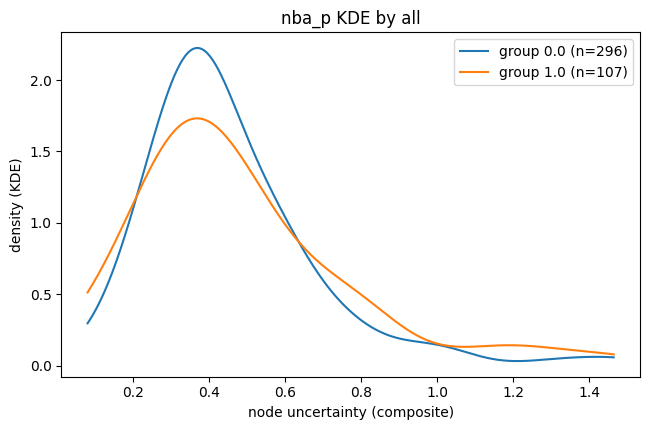

[nba_p] key='sensitive_attr' | mean gap=+0.0166 | p90 gap=+0.0707
[nba_m] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


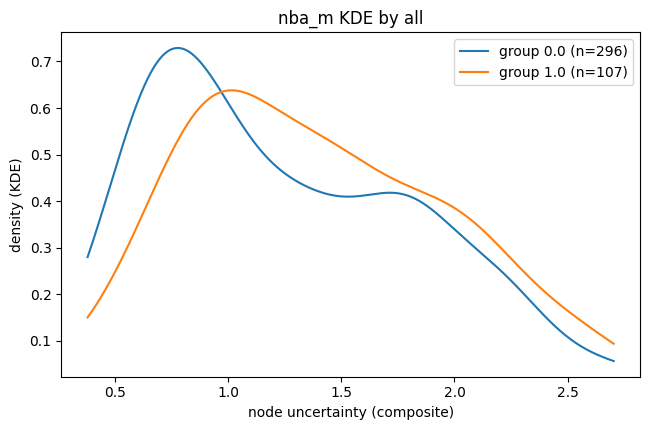

[nba_m] key='sensitive_attr' | mean gap=+0.1629 | p90 gap=+0.0129
[german_g] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


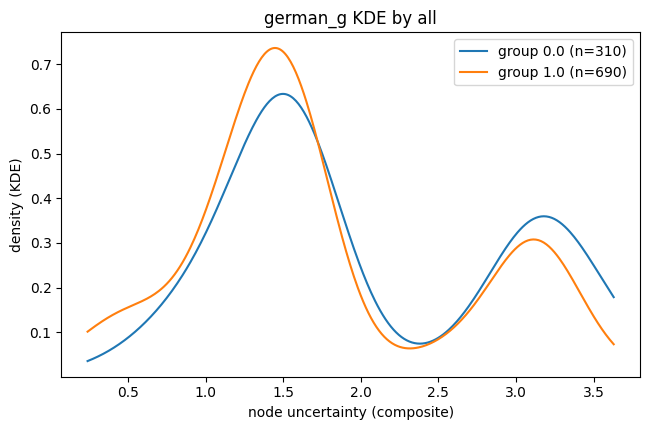

[german_g] key='sensitive_attr' | mean gap=-0.2646 | p90 gap=-0.1660
[german_f] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


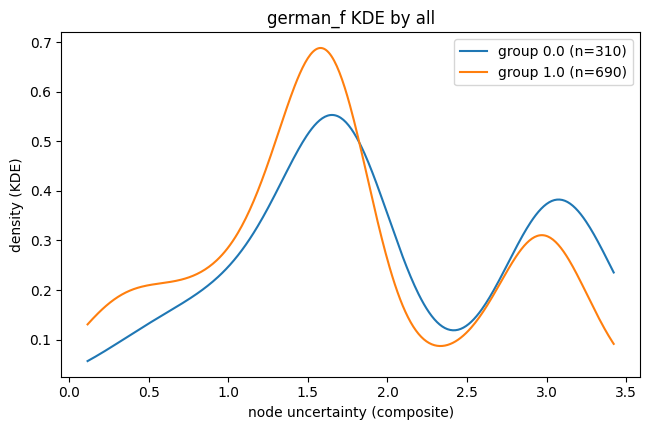

[german_f] key='sensitive_attr' | mean gap=-0.3205 | p90 gap=-0.1755
[german_s] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


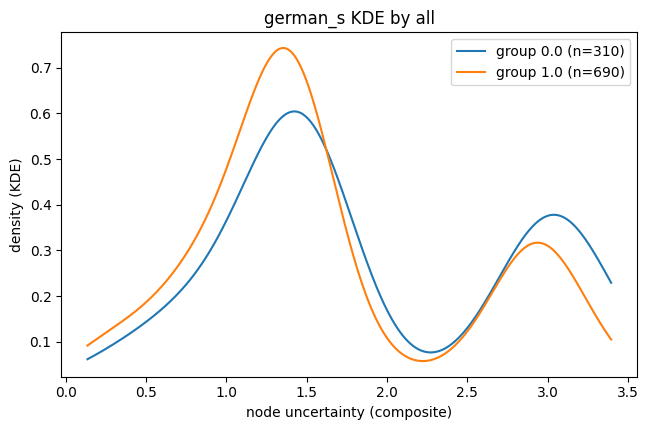

[german_s] key='sensitive_attr' | mean gap=-0.2610 | p90 gap=-0.1751
[german_t] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


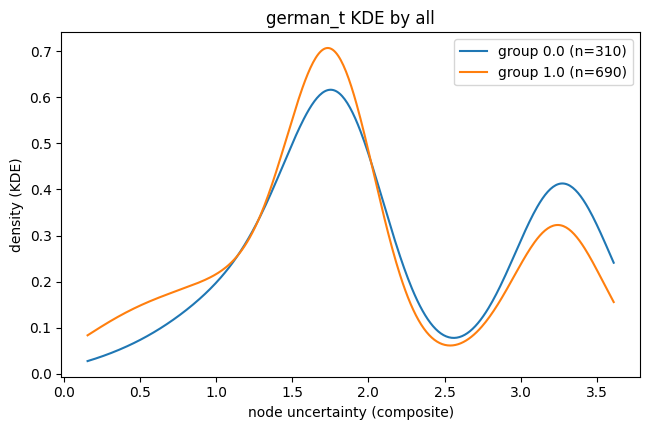

[german_t] key='sensitive_attr' | mean gap=-0.2448 | p90 gap=-0.0686
[german_h] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


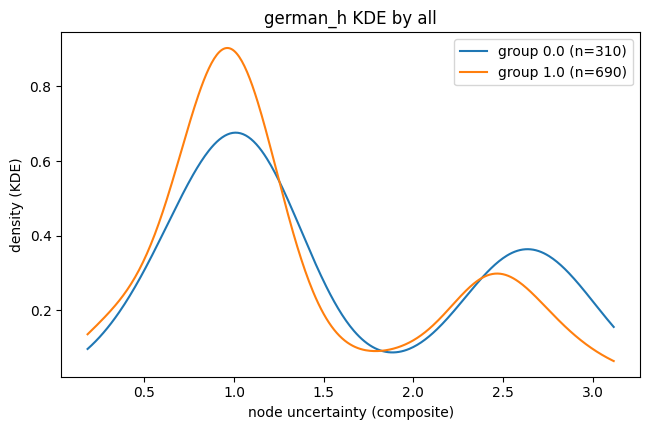

[german_h] key='sensitive_attr' | mean gap=-0.2241 | p90 gap=-0.2590
[german_e] sens_key='sensitive_attr' (binary(2-unique), n_unique≈2)


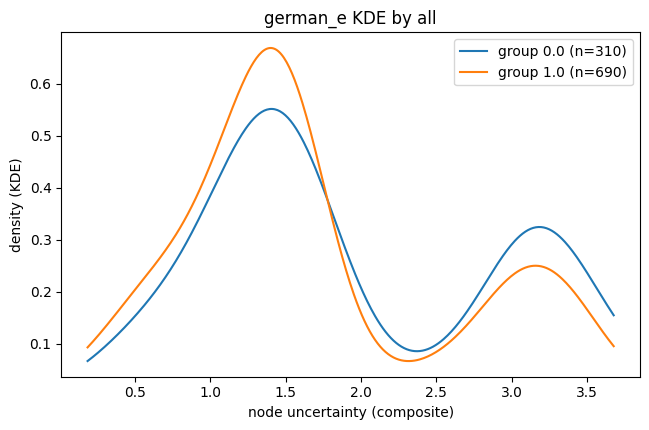

[german_e] key='sensitive_attr' | mean gap=-0.2213 | p90 gap=-0.0835


In [233]:
for ds in datasets:
    rep = get_rep_by_ds(ds, rep_pokec, rep_nba, rep_germ)
    data = dt_dict[ds]["data"]
    N = len(np.asarray(rep["node_uncertainty"]).reshape(-1))

    sens_key, meta = choose_sensitive_key_from_data(data, N, prefer_binary=True)
    print(f"[{ds}] sens_key='{sens_key}' ({meta['reason']}, n_unique≈{meta['n_unique']})")

    plot_group_uncertainty_kde(rep, dt_dict, sens_key=sens_key, seed=0, bw_method="scott")


In [339]:
def _to_numpy(x):
    try:
        return x.detach().cpu().numpy()
    except Exception:
        return np.asarray(x)

def _get_group_vec(dt_dict, ds, N, sens_key=None):
    """
    sens_key를 지정하면 그걸 쓰고,
    지정 안 하면 data에서 binary(2-unique) 후보를 자동 탐색해서 선택.
    """
    data = dt_dict[ds]["data"]

    # PyG Data 접근
    def data_keys():
        if hasattr(data, "keys") and callable(getattr(data, "keys")):
            return list(data.keys())
        if isinstance(data, dict):
            return list(data.keys())
        return []

    def data_get(k):
        if hasattr(data, "keys") and callable(getattr(data, "keys")) and k in list(data.keys()):
            return data[k]
        if isinstance(data, dict) and k in data:
            return data[k]
        if hasattr(data, k):
            return getattr(data, k)
        raise KeyError(k)

    if sens_key is not None:
        g = _to_numpy(data_get(sens_key)).reshape(-1)
        if len(g) != N:
            raise ValueError(f"sens_key='{sens_key}' length mismatch: {len(g)} != {N}")
        return g, sens_key

    # 자동 탐색: (N,) 1D 중 binary 우선
    cand = []
    for k in data_keys():
        try:
            v = _to_numpy(data_get(k)).reshape(-1)
        except Exception:
            continue
        if v.ndim == 1 and len(v) == N:
            uniq = np.unique(v[:min(N, 5000)])
            nunq = len(uniq)
            cand.append((k, nunq, uniq[:10]))

    if not cand:
        raise KeyError("data에서 (N,) 1D 후보를 못 찾음. sens_key를 직접 지정하세요.")

    # mask류 제외(자주 함정)
    bad_tokens = ["mask","split","train","val","test","idx","index","perm","fold"]
    def bad(k): return any(t in k.lower() for t in bad_tokens)

    # binary & non-bad 우선
    cand.sort(key=lambda x: x[1])
    for k, nunq, head in cand:
        if nunq == 2 and not bad(k):
            return _to_numpy(data_get(k)).reshape(-1), k

    # fallback: 가장 작은 unique 중 non-bad
    for k, nunq, head in cand:
        if not bad(k):
            return _to_numpy(data_get(k)).reshape(-1), k

    # 최후
    k = cand[0][0]
    return _to_numpy(data_get(k)).reshape(-1), k

def plot_network_uncertainty_with_group(
    rep, dt_dict,
    title="",
    seed=0,
    max_nodes=900,
    extract="kcore",     # "kcore" | "ego" | "full"
    k=12,                # kcore strength (Pokec는 보통 더 크게)
    topq=0.01,           # ego seeds: top 1%
    hop=1,
    max_seeds=40,
    sens_key=None,       # 민감집단 키를 알고 있으면 여기에 지정(추천)
):
    ds = rep["dataset"]
    if title == "":
        title = ds

    # --- uncertainty ---
    u = np.asarray(rep["node_uncertainty"], dtype=float).reshape(-1)
    N = len(u)
    u01 = (u - u.min()) / (u.max() - u.min() + 1e-12)

    # --- sensitive group ---
    g_raw, used_key = _get_group_vec(dt_dict, ds, N, sens_key=sens_key)
    g_raw = np.asarray(g_raw).reshape(-1)

    # binary 2그룹으로 정리(2개 초과면 상위 2개만)
    vals, cnts = np.unique(g_raw, return_counts=True)
    if len(vals) > 2:
        top2 = vals[np.argsort(-cnts)[:2]]
        keep = (g_raw == top2[0]) | (g_raw == top2[1])
    else:
        keep = np.ones_like(g_raw, dtype=bool)

    u01 = u01[keep]
    g_raw = g_raw[keep]

    # keep으로 줄었으면 노드 인덱스도 맞춰야 하므로: 여기서는 전체 인덱스 유지 방식 사용
    # => 대신 "keep"이 True인 노드만 시각화 대상으로 선택할 거야.
    keep_idx = np.where(keep)[0]

    # --- graph ---
    ei = np.asarray(rep["edge_index"])
    G_full = nx.Graph()
    G_full.add_edges_from(zip(ei[0], ei[1]))
    G_full.remove_edges_from(nx.selfloop_edges(G_full))

    # 우리가 시각화에 쓰는 노드 집합은 keep_idx로 제한(민감집단이 2개로 정리된 노드만)
    G_full = G_full.subgraph(keep_idx).copy()

    # --- extract subgraph ---
    rng = np.random.default_rng(seed)

    if extract == "full":
        G = G_full
        subtitle = f"(full |V|={G.number_of_nodes()})"

    elif extract == "kcore":
        # k를 올리다가 너무 커지면 자동 완화/강화 필요하지만 여기선 간단히: 목표 노드수까지 k 증가
        kk = int(k)
        H = nx.k_core(G_full, k=kk)
        # 너무 크면 k를 올려 줄이기
        while H.number_of_nodes() > max_nodes and kk < 200 and H.number_of_nodes() > 0:
            kk += 1
            H = nx.k_core(G_full, k=kk)
        # 비었으면 k를 낮추기
        while H.number_of_nodes() == 0 and kk > 1:
            kk -= 1
            H = nx.k_core(G_full, k=kk)
        G = H
        subtitle = f"(k-core k={kk}, |V|={G.number_of_nodes()})"

    elif extract == "ego":
        # top uncertainty seeds
        u_full = np.asarray(rep["node_uncertainty"], dtype=float).reshape(-1)
        u_full01 = (u_full - u_full.min()) / (u_full.max() - u_full.min() + 1e-12)
        thr = np.quantile(u_full01[keep_idx], 1 - topq)
        seeds = keep_idx[u_full01[keep_idx] >= thr].tolist()
        if len(seeds) > max_seeds:
            seeds = rng.choice(seeds, size=max_seeds, replace=False).tolist()

        nodes_union = set()
        for s in seeds:
            if s in G_full:
                nodes_union.update(nx.ego_graph(G_full, s, radius=hop).nodes())
        G = G_full.subgraph(list(nodes_union)).copy()

        if G.number_of_nodes() > max_nodes:
            must = set(seeds)
            rest = [n for n in G.nodes() if n not in must]
            add = rng.choice(rest, size=max(0, max_nodes - len(must)), replace=False).tolist()
            G = G_full.subgraph(list(must) + add).copy()

        subtitle = f"(ego-union top{int(topq*100)}%, hop={hop}, seeds<= {max_seeds}, |V|={G.number_of_nodes()})"
    else:
        raise ValueError("extract must be 'kcore'|'ego'|'full'")

    if G.number_of_nodes() == 0:
        print(f"[WARN] extracted graph empty: {ds}")
        return

    # --- group mapping (2 unique) ---
    gG = g_raw  # (keep된 노드들의 group)
    # g_raw는 keep_idx 기준으로 정렬돼 있음: g_raw[i] corresponds to keep_idx[i]
    # 노드 v의 group을 얻으려면 keep_idx에서 v의 위치를 찾아야 함 -> 빠르게 dict로
    idx2pos = {int(v): i for i, v in enumerate(keep_idx)}
    node_group = {}
    for v in G.nodes():
        node_group[v] = g_raw[idx2pos[int(v)]]

    uniq_vals = np.unique(list(node_group.values()))
    if len(uniq_vals) != 2:
        print(f"[WARN] group unique != 2 after filtering: {uniq_vals} (key={used_key})")
    g0, g1 = uniq_vals[0], uniq_vals[1]

    # edge color by group
    # edgecolors = []
    # for v in G.nodes():
    #     gv = node_group[v]
    #     edgecolors.append("green" if gv == g0 else "yellow")  # group0=black, group1=green

    # size by degree
    deg = dict(G.degree())
    max_deg = max(deg.values()) if deg else 1

    # positions
    pos = nx.spring_layout(G, seed=seed)

    # plot
    plt.figure(figsize=(6.6, 4.8))
    nx.draw_networkx_edges(G, pos, alpha=0.12, width=0.6)

    nodes = list(G.nodes())
    node_colors = [u01[int(v)] for v in nodes]  # u01은 keep_idx 정렬이라 직접 인덱싱 불가 -> 원본 u01을 써야함
    # 위 줄은 틀릴 수 있어(keep_idx 기반). 안전하게 원본 u_full01로 다시 계산
    u_full = np.asarray(rep["node_uncertainty"], dtype=float).reshape(-1)
    u_full01 = (u_full - u_full.min()) / (u_full.max() - u_full.min() + 1e-12)
    node_colors = [u_full01[int(v)] for v in nodes]

    # node_sizes = [20 + 400 * (deg[v] / (max_deg + 1e-6)) for v in nodes]
    node_sizes= 100
    
    sc = nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="coolwarm",
        # edgecolors=edgecolors,
        linewidths=1.0
    )

    # legend (group edgecolor)
    import matplotlib.patches as mpatches
    patch0 = mpatches.Patch(facecolor="white", edgecolor="black", label=f"group {g0} (edge)")
    patch1 = mpatches.Patch(facecolor="white", edgecolor="limegreen", label=f"group {g1} (edge)")
    plt.legend(handles=[patch0, patch1], loc="best", frameon=True, fontsize=8)

    plt.title(f"{title} (color=uncertainty(coolwarm), edge=sensitive group, size=degree)")
    plt.axis("off")
    plt.colorbar(sc, fraction=0.03, pad=0.02, label="normalized uncertainty")
    plt.tight_layout()
    plt.show()


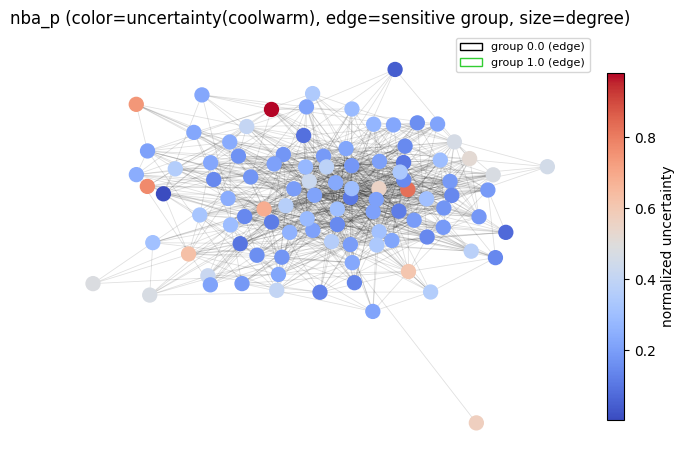

In [346]:
rep = reports_nba[0]

# plot_network_uncertainty_with_group(
#     rep, dt_dict,
#     title=rep["dataset"],
#     extract="kcore",   # 또는 "ego"
#     k=10,
#     max_nodes=100,
#     seed=0
# )

plot_network_uncertainty_with_group(
    rep, dt_dict,
    title=rep["dataset"],
    extract="ego",
    topq=0.1,     # top 1%
    hop=1,
    max_seeds=10,
    max_nodes=100,
    seed=0
)

In [173]:
def plot_simple_uncertainty_network(
    rep,
    title="",
    seed=0,
    max_nodes=1000,
    # --- extraction mode ---
    extract="kcore",          # "kcore" | "ego" | "full" | "randomwalk"
    # --- k-core params ---
    k=8,
    # --- ego params ---
    topq=0.10,                # top 10% uncertainty nodes as seeds
    hop=1,                    # ego radius
    max_seeds=200,            # 너무 많으면 union이 폭발하니 제한
):
    """
    Network plot:
      - node color = rep["node_uncertainty"] (composite)
      - node size  = degree
      - cmap = coolwarm
      - self-loops removed

    extract:
      - "kcore": k-core subgraph (중심부/안정 core 강조)
      - "ego": top-q high-uncertainty seeds의 ego-union (hotspot 강조)
      - "full": full graph (작은 그래프용)
      - "randomwalk": 기존 방식 (비교용)
    """
    # --- 데이터 꺼내기 ---
    edge_index = rep["edge_index"]
    u = np.asarray(rep["node_uncertainty"], dtype=float)

    # --- 그래프 구성 ---
    ei = np.asarray(edge_index)
    G_full = nx.Graph()
    G_full.add_edges_from(zip(ei[0], ei[1]))
    G_full.remove_edges_from(nx.selfloop_edges(G_full))

    # --------- extraction: k-core / ego / etc. ----------
    subtitle = ""

    if extract == "full":
        G = G_full

    elif extract == "kcore":
        # k가 너무 크면 비어버릴 수 있음 -> 자동 완화
        kk = int(k)
        G = nx.k_core(G_full, k=kk)
        while G.number_of_nodes() == 0 and kk > 1:
            kk -= 1
            G = nx.k_core(G_full, k=kk)
        subtitle = f"(k-core, k={kk}, |V|={G.number_of_nodes()})"

    elif extract == "ego":
        # top-q high uncertainty seed 선택
        u01 = (u - u.min()) / (u.max() - u.min() + 1e-12)
        thr = np.quantile(u01, 1 - topq)
        seeds = np.where(u01 >= thr)[0].tolist()

        # 너무 많으면 샘플링
        rng = np.random.default_rng(seed)
        if len(seeds) > max_seeds:
            seeds = rng.choice(seeds, size=max_seeds, replace=False).tolist()

        # ego-union
        nodes_union = set()
        for s in seeds:
            if s in G_full:
                nodes_union.update(nx.ego_graph(G_full, s, radius=hop).nodes())
        G = G_full.subgraph(list(nodes_union)).copy()

        # 너무 크면 줄이기(시각화 안정성)
        if G.number_of_nodes() > max_nodes:
            keep = set(seeds)
            rest = [n for n in G.nodes() if n not in keep]
            add = rng.choice(rest, size=max(0, max_nodes - len(keep)), replace=False).tolist()
            G = G_full.subgraph(list(keep) + add).copy()

        subtitle = f"(ego-union, top{int(topq*100)}% seeds (<= {max_seeds}), hop={hop}, |V|={G.number_of_nodes()})"

    elif extract == "randomwalk":
        # --- 큰 그래프면 일부만 샘플링 ---
        if G_full.number_of_nodes() > max_nodes:
            nodes = list(G_full.nodes())
            rng = np.random.default_rng(seed)
            start = rng.choice(nodes)

            walk = [start]
            cur = start
            for _ in range(10000):
                nbrs = list(G_full.neighbors(cur))
                if len(nbrs) == 0:
                    cur = rng.choice(nodes)
                else:
                    cur = rng.choice(nbrs)
                walk.append(cur)

            sub_nodes = list(dict.fromkeys(walk))[:max_nodes]
            G = G_full.subgraph(sub_nodes).copy()
            subtitle = f"(random-walk sample, |V|={G.number_of_nodes()})"
        else:
            G = G_full
            subtitle = f"(full graph, |V|={G.number_of_nodes()})"

    else:
        raise ValueError('extract must be one of: "kcore", "ego", "full", "randomwalk"')

    # 안전장치
    if G.number_of_nodes() == 0:
        print(f"[WARN] Extracted graph is empty. (extract={extract})")
        return

    # --- degree ---
    deg = dict(G.degree())
    max_deg = max(deg.values()) if len(deg) else 1

    # --- layout ---
    pos = nx.spring_layout(G, seed=seed)

    # --- plot ---
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_edges(G, pos, alpha=0.12, width=0.6)

    nodes = list(G.nodes())
    node_colors = [u[v] for v in nodes]  # u는 원본 노드 인덱스 기준
    node_sizes = [20 + 100 * (deg[v] / (max_deg + 1e-6)) for v in nodes]

    sc = nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="coolwarm"
    )

    plt.title(f"{title} {subtitle}\n(color = composite node uncertainty, size = degree)")
    plt.axis("off")
    plt.colorbar(sc, fraction=0.03, pad=0.02, label="node uncertainty")
    plt.tight_layout()
    plt.show()


In [186]:
def build_graph_from_rep(rep, undirected=True, remove_self_loops=True):
    ei = np.asarray(rep["edge_index"])
    G = nx.Graph() if undirected else nx.DiGraph()
    G.add_edges_from(zip(ei[0], ei[1]))
    if remove_self_loops:
        G.remove_edges_from(nx.selfloop_edges(G))
    return G

def find_adaptive_k_for_kcore(
    G,
    max_nodes=800,          # 목표: k-core 노드 수가 이 이하가 되도록
    min_nodes=200,          # 너무 작아지면 그림이 빈약함(하한)
    k_start=1,
    k_max=200,
    step=1,
    prefer_largest_cc=True  # 연결 성분 중 가장 큰 CC만 대상으로 k-core 찾기
):
    """
    k를 올려가며 k-core 크기를 줄이고,
    [min_nodes, max_nodes] 범위에 들어오는 '가장 작은 k'를 선택.
    없다면: max_nodes를 처음으로 밑도는 k(너무 작으면) 또는 가장 근접한 k를 반환.
    """
    if prefer_largest_cc:
        # giant component에서만 계산 (Pokec류에서 훨씬 안정적)
        if not nx.is_connected(G):
            largest_cc = max(nx.connected_components(G), key=len)
            G = G.subgraph(largest_cc).copy()

    best = None  # (k, n_nodes, H)
    first_below = None  # max_nodes 아래로 처음 내려간 지점
    last_nonempty = None

    for k in range(k_start, k_max + 1, step):
        H = nx.k_core(G, k=k)
        n = H.number_of_nodes()
        if n > 0:
            last_nonempty = (k, n, H)

        # 목표 범위에 들어오면 바로 반환(가장 작은 k)
        if min_nodes <= n <= max_nodes and n > 0:
            return {"k": k, "n_nodes": n, "subgraph": H, "status": "hit_target_range"}

        # max_nodes 아래로 처음 내려간 지점 기록
        if first_below is None and n > 0 and n < max_nodes:
            first_below = (k, n, H)

        # 완전히 비면 여기서 종료 (k가 너무 커짐)
        if n == 0:
            break

        # best(근접도) 업데이트: max_nodes에 가장 가까운 n을 우선
        if n > 0:
            dist = abs(n - max_nodes)
            if best is None or dist < best[0]:
                best = (dist, k, n, H)

    # 목표 구간 못 찾은 경우 처리
    if first_below is not None:
        k, n, H = first_below
        return {"k": k, "n_nodes": n, "subgraph": H, "status": "first_below_max_nodes"}

    if last_nonempty is not None:
        k, n, H = last_nonempty
        return {"k": k, "n_nodes": n, "subgraph": H, "status": "last_nonempty_core"}

    # 여기 오면 그래프 자체가 비정상적으로 작거나 문제
    return {"k": None, "n_nodes": 0, "subgraph": nx.Graph(), "status": "empty_graph"}

def summarize_kcore_curve(G, k_max=50):
    """
    디버깅/감각 잡기용: k별 k-core 노드 수를 빠르게 찍어본다.
    """
    sizes = []
    for k in range(1, k_max + 1):
        H = nx.k_core(G, k=k)
        sizes.append((k, H.number_of_nodes(), H.number_of_edges()))
        if H.number_of_nodes() == 0:
            break
    return sizes

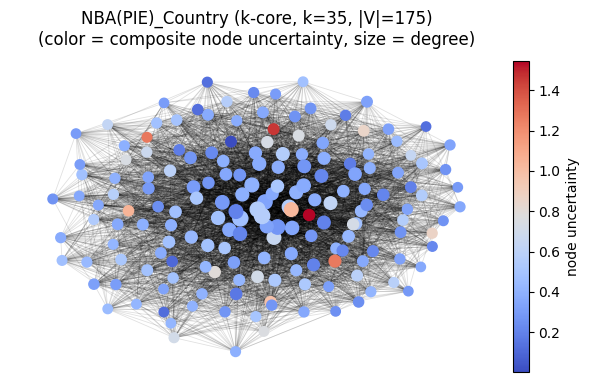

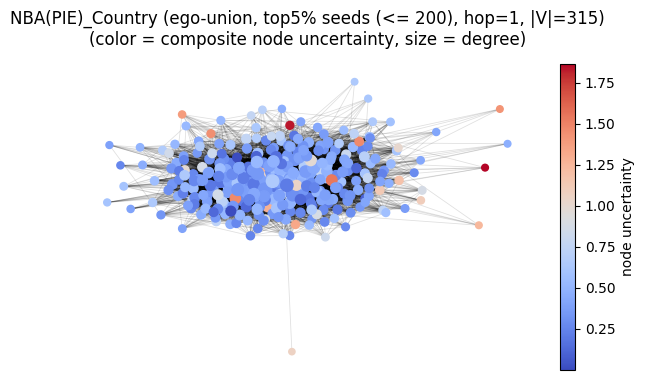

In [190]:
rep = reports_nba[0]  # reports_pokec(3), reports_nba(1), reports_german(5)

# 1) k-core로 (중심부 구조 강조)
# “High uncertainty nodes are largely located outside the structural core.”
plot_simple_uncertainty_network(rep, title=rep['dataset'], extract="kcore", k=400, seed=0)


# 2) high-uncertainty ego-graph로 (hotspot 강조)
# “Uncertainty concentrates within localized neighborhoods, indicating structural ambiguity rather than isolated noise.”
plot_simple_uncertainty_network(rep, title=rep['dataset'], extract="ego", topq=0.05, hop=1, seed=0)

In [296]:
reps = reports_pokec  # reports_pokec(3), reports_nba(1), reports_german(5)

for i in range(len(reps)):
    rep = reps[i]
    plot_simple_uncertainty_network(rep, title=rep['dataset'], seed=0, max_nodes=500)

KeyboardInterrupt: 